# **Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

## **Edición 2025**


----

# Trabajo práctico entregable - parte 2


Trabajaremos con la base de datos de `melb_data` presentada a continuación.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import seaborn
seaborn.set_context('talk')

In [ ]:
# Acá deberían leer el conjunto de datos que ya tienen.
melb_df = pd.read_csv(
    'https://cs.famaf.unc.edu.ar/~mteruel/datasets/diplodatos/melb_data.csv')
melb_df[:3]

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0


* Cargamos los datos y visualizamos las primeras 3 filas del dataset

## Ejercicio 1: Encoding

1. Seleccionar todas las filas y columnas del conjunto de datos, **excepto** `BuildingArea` y `YearBuilt`, que volveremos a imputar más adelante.

2. Aplicar una codificación One-hot encoding a cada fila, tanto para variables numéricas como categóricas. Si lo consideran necesario, pueden volver a reducir el número de categorías únicas.

Algunas opciones:
  1. Utilizar `OneHotEncoder` junto con el parámetro `categories` para las variables categóricas y luego usar `numpy.hstack` para concatenar el resultado con las variables numéricas.
  2. `DictVectorizer` con algunos pasos de pre-proceso previo.

Recordar también que el atributo `pandas.DataFrame.values` permite acceder a la matriz de numpy subyacente a un DataFrame.


### 1.1) Seleccionar todas las filas y columnas del conjunto de datos, excepto BuildingArea y YearBuilt, que volveremos a imputar más adelante.

In [ ]:
# Se genera el Data Frame 'melb_df_1_1' para el Ejercicio 1.1
melb_df_1_1=melb_df.copy()

Se muestran las columnas que tenemos en el Data Frame

In [ ]:
melb_df_1_1.columns

Index(['Suburb', 'Address', 'Rooms', 'Type', 'Price', 'Method', 'SellerG',
       'Date', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car',
       'Landsize', 'BuildingArea', 'YearBuilt', 'CouncilArea', 'Lattitude',
       'Longtitude', 'Regionname', 'Propertycount'],
      dtype='object')

Se seleccionan todas las columnas excepto **BuildingArea** y **YearBuilt**

In [ ]:
columnasRelevantes=['Suburb', 'Address', 'Rooms', 'Type', 'Price', 'Method', 'SellerG',
       'Date', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car',
       'Landsize', 'CouncilArea', 'Lattitude','Longtitude', 'Regionname', 'Propertycount']
melb_df_1_1=melb_df_1_1[columnasRelevantes]
melb_df_1_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  object 
 6   SellerG        13580 non-null  object 
 7   Date           13580 non-null  object 
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  CouncilArea    12211 non-null  object 
 15  Lattitude      13580 non-null  float64
 16  Longtitude     13580 non-null  float64
 17  Regionname     13580 non-null  object 
 18  Proper

* Validamos exitosamente que no se muestren las columnas excluidas BuildingArea y YearBuilt.

Se muestran los datos en forma de tabla y en forma grafica para una rapida exploracion visual

In [ ]:
melb_df_1_1

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,2.0,1.0,1.0,202.0,Yarra,-37.79960,144.99840,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,2.0,1.0,0.0,156.0,Yarra,-37.80790,144.99340,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,3.0,2.0,0.0,134.0,Yarra,-37.80930,144.99440,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,3.0,2.0,1.0,94.0,Yarra,-37.79690,144.99690,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,3.0,1.0,2.0,120.0,Yarra,-37.80720,144.99410,Northern Metropolitan,4019.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13575,Wheelers Hill,12 Strada Cr,4,h,1245000.0,S,Barry,26/08/2017,16.7,3150.0,4.0,2.0,2.0,652.0,NaN,-37.90562,145.16761,South-Eastern Metropolitan,7392.0
13576,Williamstown,77 Merrett Dr,3,h,1031000.0,SP,Williams,26/08/2017,6.8,3016.0,3.0,2.0,2.0,333.0,NaN,-37.85927,144.87904,Western Metropolitan,6380.0
13577,Williamstown,83 Power St,3,h,1170000.0,S,Raine,26/08/2017,6.8,3016.0,3.0,2.0,4.0,436.0,NaN,-37.85274,144.88738,Western Metropolitan,6380.0
13578,Williamstown,96 Verdon St,4,h,2500000.0,PI,Sweeney,26/08/2017,6.8,3016.0,4.0,1.0,5.0,866.0,NaN,-37.85908,144.89299,Western Metropolitan,6380.0


### 1.2) Aplicar una codificación One-hot encoding a cada fila, tanto para variables numéricas como categóricas. Si lo consideran necesario, pueden volver a reducir el número de categorías únicas.

Algunas opciones:
1. Utilizar OneHotEncoder junto con el parámetro categories para las variables categóricas y luego usar numpy.hstack para concatenar el resultado con las variables numéricas.
2. DictVectorizer con algunos pasos de pre-proceso previo.
Recordar también que el atributo pandas.DataFrame.values permite acceder a la matriz de numpy subyacente a un DataFrame.

In [ ]:
# Se genera el Data Frame 'melb_df_1_2' para el Ejercicio 1.2
melb_df_1_2=melb_df_1_1.copy()

* Generamos una copia para poder trabajar con el dataset, Usamos .copy() para tener una versión independiente para experimentar o transformar sin arruinar los datos base.

Se disminuye el numero de variables categoricas, a codificar, para evitar manejar un volumen muy grande de datos.

In [ ]:
columnasRelevantes=['Suburb', 'Address', 'Rooms', 'Type', 'Price', 'Method', 'SellerG',
       'Date', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car',
       'Landsize', 'CouncilArea', 'Lattitude',
       'Longtitude', 'Regionname', 'Propertycount']

# Primero: del total de columnas se dividen entre numericas y categoricas
columnasCategoricas = melb_df_1_2.select_dtypes(exclude=np.number).columns
columnasNumericas = melb_df_1_2.select_dtypes(include=np.number).columns

# Segudo: se determina cuantos valores unicos hay en cada columna categorica
melb_df_1_2[columnasCategoricas].nunique()



,0
Suburb,314
Address,13378
Type,3
Method,5
SellerG,268
Date,58
CouncilArea,33
Regionname,8


* Definimos columnas relevantes (columnasRelevantes), luego separamos variables categoricas y numericas, para aplicar tratamientos distintos:
  
  * A las numéricas: poder normalizarlas o imputarlas.
  * A las categóricas: poder codificarlas o reducirlas.
* Finalmente validamos la cardinalidad de las columnas categóricas (.nunique()).


Se eliminan las variables 'Suburb', 'Address', 'SellerG' , 'Date' y 'CouncilArea' ya que tienen demasiadas valores diferentes y terminan generando un Data Frame muy grande.

In [ ]:
columnasCategoricasReducidas=['Type','Method', 'Regionname']

melb_df_1_2[columnasCategoricasReducidas].nunique()

,0
Type,3
Method,5
Regionname,8


Reducimos aun mas las variables, seleccionando solamente 3 columnas
Realizamos esta acción, para evitar el problema de procesamiento y para poder codificarlas con técnicas como OneHotEncoding o get_dummies.

Ahora si pasamos a realizar la codificacion, mediante 3 opciones diferentes:
1. [OneHotEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) y [np.hstack](https://numpy.org/doc/stable/reference/generated/numpy.hstack.html)
2. [DictVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.DictVectorizer.html)
3. get_dummies y concat

### Opcion 1

In [ ]:
# Opcion 1
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, dtype=int)
encoder.fit(melb_df_1_2[columnasCategoricasReducidas])
encoder.categories_

[array(['h', 't', 'u'], dtype=object),
 array(['PI', 'S', 'SA', 'SP', 'VB'], dtype=object),
 array(['Eastern Metropolitan', 'Eastern Victoria',
        'Northern Metropolitan', 'Northern Victoria',
        'South-Eastern Metropolitan', 'Southern Metropolitan',
        'Western Metropolitan', 'Western Victoria'], dtype=object)]

In [ ]:
encoded = encoder.transform(melb_df_1_2[columnasCategoricasReducidas])
encoded

array([[1, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       ...,
       [1, 0, 0, ..., 0, 1, 0],
       [1, 0, 0, ..., 0, 1, 0],
       [1, 0, 0, ..., 0, 1, 0]])

* Aplicamos la codificación aprendida por el encoder en el paso anterior a las mismas columnas categóricas.

* Validamos que el codigo devuelva un array numpy con la representación one-hot de las columnas, donde cada columna categórica se convierte en varias columnas binarias (0 o 1), una por cada categoría posible.

**Resultado (encoded):**
* Array de 2 dimensiones, con tantas filas como el DataFrame original y tantas columnas como categorías totales en todas las columnas (habiamos seleccionado 3 variables columnasCategoricasReducidas).

In [ ]:
# Unificamos las variables numericas, categoricas ya codificadas y los nombres de columnas

# Variables numericas
variablesNumericas=melb_df_1_2[columnasNumericas].values


# Categoricas ya codificadas
variablesCategoricas=encoded

# Nombres de columnas
nombresColumnasDeVariablesCategoricas=encoder.get_feature_names_out(columnasCategoricasReducidas)
nombresColumnasCompletos=list(melb_df_1_2.drop(columns=columnasCategoricas).columns) + list(nombresColumnasDeVariablesCategoricas)

# Unificamos los datos
melb_array_1_2_OneHotEncoding=np.hstack([variablesNumericas,variablesCategoricas]) # Se unifican las variables numericas y categoricas
melb_df_1_2_OneHotEncoding = pd.DataFrame(melb_array_1_2_OneHotEncoding, columns=nombresColumnasCompletos) # Se convierte a DataFRame y se le agrega el nombre de las columnas

melb_df_1_2_OneHotEncoding.head()

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,Lattitude,Longtitude,...,Method_SP,Method_VB,Regionname_Eastern Metropolitan,Regionname_Eastern Victoria,Regionname_Northern Metropolitan,Regionname_Northern Victoria,Regionname_South-Eastern Metropolitan,Regionname_Southern Metropolitan,Regionname_Western Metropolitan,Regionname_Western Victoria
0,2.0,1480000.0,2.5,3067.0,2.0,1.0,1.0,202.0,-37.7996,144.9984,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,2.0,1035000.0,2.5,3067.0,2.0,1.0,0.0,156.0,-37.8079,144.9934,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,3.0,1465000.0,2.5,3067.0,3.0,2.0,0.0,134.0,-37.8093,144.9944,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,3.0,850000.0,2.5,3067.0,3.0,2.0,1.0,94.0,-37.7969,144.9969,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,4.0,1600000.0,2.5,3067.0,3.0,1.0,2.0,120.0,-37.8072,144.9941,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


*  Este bloque junta todo el procesamiento y arma el DataFrame final con variables numéricas y categóricas codificadas, con los siguientes pasos:

1. Separamos las variables numéricas y las categóricas ya codificadas (one-hot) en arrays de NumPy.

2. Creamos nombres para las columnas codificadas a partir del encoder.

3. Unimos los nombres de las columnas numéricas originales y los nombres de las variables categóricas codificadas para formar la lista completa de columnas.

4. Concatenamos horizontalmente los arrays numéricos y categóricos en uno solo.

5. Convertimos esa matriz combinada en un DataFrame de pandas con los nombres de columnas correctos.

6. Mostramos a las primeras filas del DataFrame final con todas las variables listas para análisis o modelado.

In [ ]:
melb_df_1_2_OneHotEncoding.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 27 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Rooms                                  13580 non-null  float64
 1   Price                                  13580 non-null  float64
 2   Distance                               13580 non-null  float64
 3   Postcode                               13580 non-null  float64
 4   Bedroom2                               13580 non-null  float64
 5   Bathroom                               13580 non-null  float64
 6   Car                                    13518 non-null  float64
 7   Landsize                               13580 non-null  float64
 8   Lattitude                              13580 non-null  float64
 9   Longtitude                             13580 non-null  float64
 10  Propertycount                          13580 non-null  float64
 11  Ty

* Utilizamos la función (.info()), para tener una vista rápida del tamaño y estructura de tu DataFrame, para ver si hay valores faltantes (columnas donde el número de no nulos es menor que el total de filas), para confirmar tipos de datos después de transformaciones como el one-hot encoding.
* En resumen podemos confirmar:
 * Que tiene todas las filas originales.
 * Que las columnas numéricas están intactas.
 * Que las columnas categóricas ahora aparecen como muchas columnas binarias (0/1), probablemente con tipo int64.
 * Que no haya valores faltantes en esas columnas (era lo esperable, ya que consideramos que el one-hot está bien aplicado).

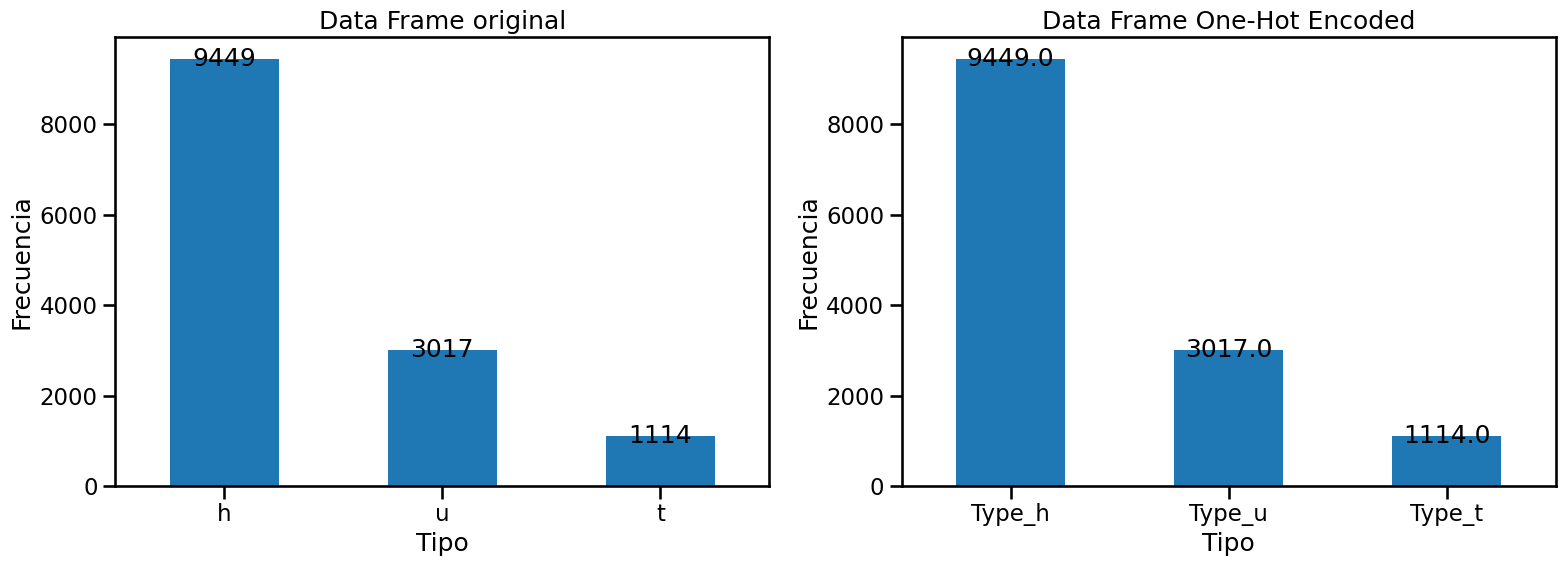

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Data Frame original
melb_df_1_2['Type'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('Data Frame original')
axes[0].set_xlabel('Tipo')
axes[0].set_ylabel('Frecuencia')
axes[0].tick_params(axis='x', rotation=0)

# Etiquetar las barras del primer gráfico
for bar in axes[0].patches:
  yval = bar.get_height()
  axes[0].text(bar.get_x() + bar.get_width()/2., yval + 0.1, yval, ha='center', va='center')


# Gráfico 2: Data Frame One-Hot Encoded
columnas_tipo = ['Type_h', 'Type_u', 'Type_t']
data_para_grafico = melb_df_1_2_OneHotEncoding[columnas_tipo].sum()
bars2 = data_para_grafico.plot(kind='bar', ax=axes[1])
axes[1].set_title('Data Frame One-Hot Encoded')
axes[1].set_xlabel('Tipo')
axes[1].set_ylabel('Frecuencia')
axes[1].tick_params(axis='x', rotation=0) # Para que las etiquetas del eje x sean horizontales

# Etiquetar las barras del segundo gráfico
for bar in bars2.patches:
  yval = bar.get_height()
  axes[1].text(bar.get_x() + bar.get_width()/2., yval + 0.1, yval, ha='center', va='center')


plt.tight_layout() # Ajustar el diseño para evitar solapamiento
plt.show()


* En este grafico, visualizamos
 * A la izquierda: Las frecuencias originales de cada categoría en Type.
 * A la derecha: Las mismas frecuencias pero contadas desde las columnas codificadas en One-Hot Encoding.
 * Las barras y valores, como lo esperabamos coinciden, mostrando que la codificación respeta la distribución original.

### Opcion 2

In [ ]:
# Opcion 2
from sklearn.feature_extraction import DictVectorizer


# Convertir el conjunto de datos en una lista de diccionarios
feature_dict = list(melb_df_1_2[columnasCategoricasReducidas].T.to_dict().values())

vec = DictVectorizer()
feature_matrix = vec.fit_transform(feature_dict)
feature_matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 40740 stored elements and shape (13580, 16)>

* DictVectorizer es una alternativa a OneHotEncoder, segun la teoria deberia ser especialmente útil cuando trabajamos con datos tipo diccionario o con datasets heterogéneos.



In [ ]:
melb_df_1_2_DictVectorizer = pd.DataFrame(feature_matrix.toarray(), columns=vec.get_feature_names_out())
melb_df_1_2_DictVectorizer

,Method=PI,Method=S,Method=SA,Method=SP,Method=VB,Regionname=Eastern Metropolitan,Regionname=Eastern Victoria,Regionname=Northern Metropolitan,Regionname=Northern Victoria,Regionname=South-Eastern Metropolitan,Regionname=Southern Metropolitan,Regionname=Western Metropolitan,Regionname=Western Victoria,Type=h,Type=t,Type=u
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13575,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
13576,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
13577,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
13578,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [ ]:
# Añadimos las variables numericas al DataFrame
melb_df_1_2_DictVectorizer = pd.concat([melb_df_1_2.drop(columns=columnasCategoricas), melb_df_1_2_DictVectorizer], axis = 1)

melb_df_1_2_DictVectorizer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 27 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Rooms                                  13580 non-null  int64  
 1   Price                                  13580 non-null  float64
 2   Distance                               13580 non-null  float64
 3   Postcode                               13580 non-null  float64
 4   Bedroom2                               13580 non-null  float64
 5   Bathroom                               13580 non-null  float64
 6   Car                                    13518 non-null  float64
 7   Landsize                               13580 non-null  float64
 8   Lattitude                              13580 non-null  float64
 9   Longtitude                             13580 non-null  float64
 10  Propertycount                          13580 non-null  float64
 11  Me

* Esta última version de código, que es similar a la Opción 1, une las variables numéricas con las categóricas codificadas, pero usando DictVectorizer en vez de OneHotEncoder.

* Juntamos variables numéricas + categóricas (ya codificadas con DictVectorizer), aseguramos que todo esté en un solo DataFrame, con nombres de columnas adecuados.

* Con el .info() verificamos que la transformación fue exitosa.

### Opcion 3

In [ ]:
# Opcion 3

# Creamos las variables binarias con el método get_dummies.
dummies = pd.get_dummies(melb_df_1_2[columnasCategoricasReducidas], drop_first = False,dtype=int)

# Añadimos las variables binarias al DataFrame
melb_df_1_2_dummis = pd.concat([melb_df_1_2.drop(columns=columnasCategoricas), dummies], axis = 1)

melb_df_1_2_dummis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 27 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Rooms                                  13580 non-null  int64  
 1   Price                                  13580 non-null  float64
 2   Distance                               13580 non-null  float64
 3   Postcode                               13580 non-null  float64
 4   Bedroom2                               13580 non-null  float64
 5   Bathroom                               13580 non-null  float64
 6   Car                                    13518 non-null  float64
 7   Landsize                               13580 non-null  float64
 8   Lattitude                              13580 non-null  float64
 9   Longtitude                             13580 non-null  float64
 10  Propertycount                          13580 non-null  float64
 11  Ty

In [ ]:
# Opcion 3 (todas las columnas categoricas excepto BuildingArea y YearBuilt)

columnas_categoricas = melb_df_1_2.select_dtypes(exclude=np.number).columns
columnas_numericas = melb_df_1_2.select_dtypes(include=np.number).columns

# Creamos las variables binarias con el método get_dummies.
dummies_2 = pd.get_dummies(melb_df_1_2[columnas_categoricas], drop_first = False,dtype=int)
# Añadimos las variables binarias al DataFrame
pd.concat([melb_df_1_2.drop(columns=columnas_categoricas), dummies_2], axis = 1).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Columns: 14078 entries, Rooms to Regionname_Western Victoria
dtypes: float64(10), int64(14068)
memory usage: 1.4 GB



* Se realiza el Encoding para todas las columnas del dataset original y se obtiene un DataFrame de:
  * 13580 filas
  * 14078 columnas

* Por lo tanto, para evitar problemas de memoria RAM, se utilizara el DataFrame codificado reducido, donde como se menciono antreriormente, se codificaron unicamente las columnas'Type', 'Method', 'Regionname'. Este DataFrame tiene:
  * 13580 filas
  * 27 columnas

* En caso de necesitar usar el Data Frame completo se podria utilizar el entorno de ejecucion TPU v2-8, que cuenta con una memoria RAM suficiente para manejar la cantidad de datos.

### **CONCLUSIÓN: Opción 1, 2 y 3**

Si bien validamos que hay varias formas de resolver lo solicitado, consideramos que la forma más rapida, directa y suficiente es la **Opcion 3 ** mediante el metodo de pandas "get_dummis" y "concat", ya que requiere menos codigo y transformaciones.

* Con get_dummies, vemos que es muy simple, que no requiere fit/transform, y segun la teoria deberia ser ideal para prototipos y análisis rápidos.



# Ejercicio 2: Imputación por KNN

En el teórico se presentó el método `IterativeImputer` para imputar valores faltantes en variables numéricas. Sin embargo, los ejemplos presentados sólo utilizaban algunas variables numéricas presentes en el conjunto de datos. En este ejercicio, utilizaremos la matriz de datos codificada para imputar datos faltantes de manera más precisa.

1. Agregue a la matriz obtenida en el punto anterior las columnas `YearBuilt` y `BuildingArea`.
2. Aplique una instancia de `IterativeImputer` con un estimador `KNeighborsRegressor` para imputar los valores de las variables. ¿Es necesario estandarizar o escalar los datos previamente?
3. Realice un gráfico mostrando la distribución de cada variable antes de ser imputada, y con ambos métodos de imputación.

## 2.1) Agregue a la matriz obtenida en el punto anterior las columnas `YearBuilt` y `BuildingArea`.

In [ ]:
# Se genera el Data Frame 'melb_df_2_1' para el Ejercicio 2.1
melb_df_2_1_reducido=melb_df_1_2_dummis.copy() # solo las columnas 'Type','Method'y 'Regionname' fueron codificadas

Se agregan las columnas 'YearBuilt' y 'BuildingArea' en ambos Data Frame mediante el metodo concat de pandas.

In [ ]:
# Data Frame Reducido
melb_df_2_1_reducido=pd.concat([melb_df_2_1_reducido, melb_df['YearBuilt'],melb_df['BuildingArea']], axis = 1)
melb_df_2_1_reducido

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,Lattitude,Longtitude,...,Regionname_Eastern Metropolitan,Regionname_Eastern Victoria,Regionname_Northern Metropolitan,Regionname_Northern Victoria,Regionname_South-Eastern Metropolitan,Regionname_Southern Metropolitan,Regionname_Western Metropolitan,Regionname_Western Victoria,YearBuilt,BuildingArea
0,2,1480000.0,2.5,3067.0,2.0,1.0,1.0,202.0,-37.79960,144.99840,...,0,0,1,0,0,0,0,0,NaN,NaN
1,2,1035000.0,2.5,3067.0,2.0,1.0,0.0,156.0,-37.80790,144.99340,...,0,0,1,0,0,0,0,0,1900.0,79.0
2,3,1465000.0,2.5,3067.0,3.0,2.0,0.0,134.0,-37.80930,144.99440,...,0,0,1,0,0,0,0,0,1900.0,150.0
3,3,850000.0,2.5,3067.0,3.0,2.0,1.0,94.0,-37.79690,144.99690,...,0,0,1,0,0,0,0,0,NaN,NaN
4,4,1600000.0,2.5,3067.0,3.0,1.0,2.0,120.0,-37.80720,144.99410,...,0,0,1,0,0,0,0,0,2014.0,142.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13575,4,1245000.0,16.7,3150.0,4.0,2.0,2.0,652.0,-37.90562,145.16761,...,0,0,0,0,1,0,0,0,1981.0,NaN
13576,3,1031000.0,6.8,3016.0,3.0,2.0,2.0,333.0,-37.85927,144.87904,...,0,0,0,0,0,0,1,0,1995.0,133.0
13577,3,1170000.0,6.8,3016.0,3.0,2.0,4.0,436.0,-37.85274,144.88738,...,0,0,0,0,0,0,1,0,1997.0,NaN
13578,4,2500000.0,6.8,3016.0,4.0,1.0,5.0,866.0,-37.85908,144.89299,...,0,0,0,0,0,0,1,0,1920.0,157.0


* melb_df_2_1_reducido, es un subconjunto de variables (más eficiente y rápido).


## 2.2) Aplique una instancia de `IterativeImputer` con un estimador `KNeighborsRegressor` para imputar los valores de las variables. ¿Es necesario estandarizar o escalar los datos previamente?

Documentacion:
* [IterativeImputer](https://scikit-learn.org/stable/modules/generated/sklearn.impute.IterativeImputer.html)
* [KNeighborsRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html)
* [ExtraTreesRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.ExtraTreesRegressor.html)
* [BayesianRidge](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.BayesianRidge.html)
* [DecisionTreeRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html)

In [ ]:
# Se genera el Data Frame 'melb_df_2_2' para el Ejercicio 2.2
melb_df_2_2_reducido=melb_df_2_1_reducido.copy() # solo las columnas 'Type','Method'y 'Regionname' fueron codificadas

* Realizamos copia para no trabajar con los dataset originales
* Podemos avanzar con la comparación de los datasets, para saber si imputar con más o menos columnas influye en la calidad de los valores imputados para 'YearBuilt' y 'BuildingArea'.

Se realiza una imputacion con los 4 siguientes estimadores de la libreria Sklearn:
* KNeighborsRegressor
* ExtraTreesRegressor
* BayesianRidge
* DecisionTreeRegressor

La imputacion se realizara en las columnas numericas con datos faltantes:

In [ ]:
# Columnas numericas con datos faltantes
melb_df_2_2_reducido.isnull().sum()[melb_df_2_2_reducido.isnull().sum() > 0]

,0
Car,62
YearBuilt,5375
BuildingArea,6450


* Validamos si las columnas tienen valores faltantes o nulos.

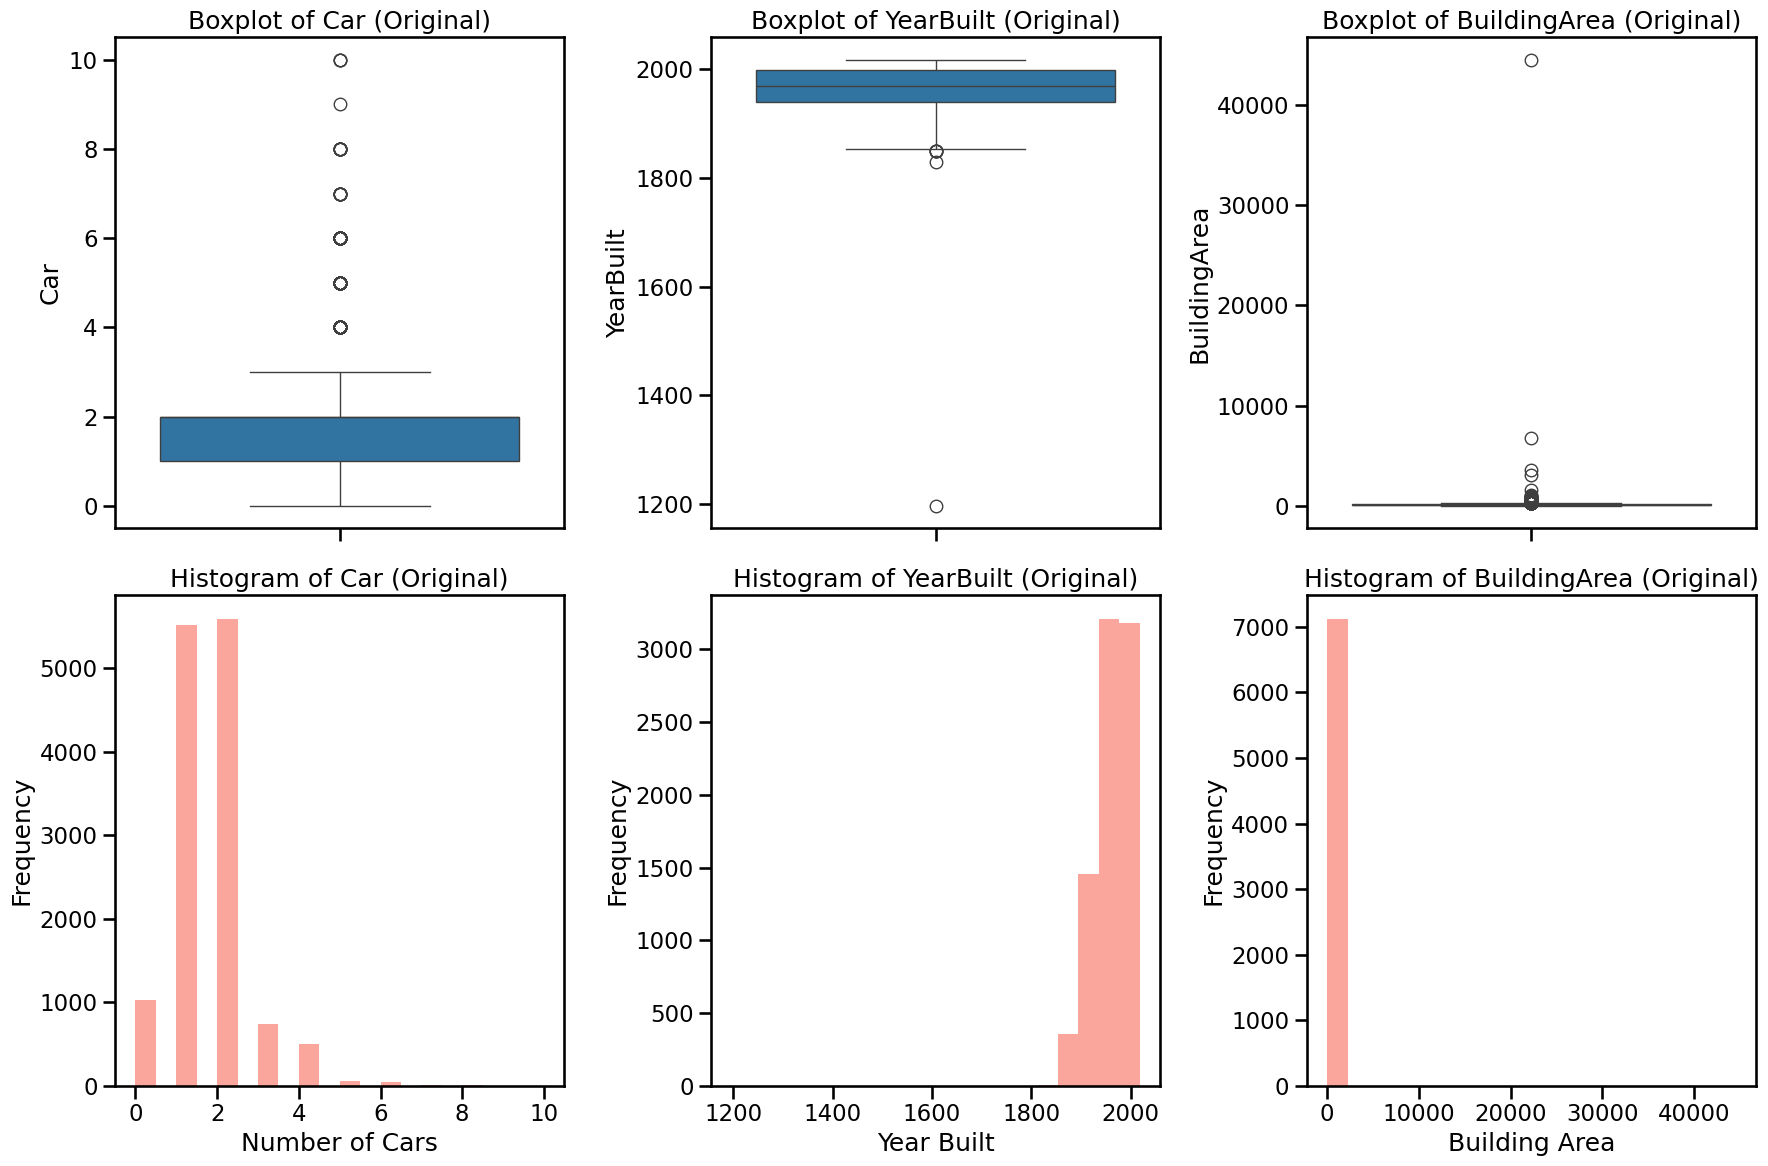

In [ ]:
plt.figure(figsize=(18, 12))

# Car
plt.subplot(2, 3, 1)
seaborn.boxplot(y=melb_df_2_2_reducido['Car'])
plt.title('Boxplot of Car (Original)')

plt.subplot(2, 3, 4)
plt.hist(melb_df_2_2_reducido['Car'], bins=20, alpha=0.7, color='salmon')
plt.title('Histogram of Car (Original)')
plt.xlabel('Number of Cars')
plt.ylabel('Frequency')

# YearBuilt
plt.subplot(2, 3, 2)
seaborn.boxplot(y=melb_df_2_2_reducido['YearBuilt'])
plt.title('Boxplot of YearBuilt (Original)')

plt.subplot(2, 3, 5)
plt.hist(melb_df_2_2_reducido['YearBuilt'], bins=20, alpha=0.7, color='salmon')
plt.title('Histogram of YearBuilt (Original)')
plt.xlabel('Year Built')
plt.ylabel('Frequency')

# BuildingArea
plt.subplot(2, 3, 3)
seaborn.boxplot(y=melb_df_2_2_reducido['BuildingArea'])
plt.title('Boxplot of BuildingArea (Original)')

plt.subplot(2, 3, 6)
plt.hist(melb_df_2_2_reducido['BuildingArea'], bins=20, alpha=0.7, color='salmon')
plt.title('Histogram of BuildingArea (Original)')
plt.xlabel('Building Area')
plt.ylabel('Frequency')


plt.tight_layout()
# ✅ Guardar como imagen (PNG, alta calidad)
plt.savefig("data_original.png", dpi=300, bbox_inches='tight')
plt.show()

* Visualizamos la distribución original (con valores faltantes incluidos) de tres variables:
 * Car: cantidad de cocheras.
 * YearBuilt: año de construcción.
 * BuildingArea: área del edificio.

* Con este grafico queremos:
  * Detectar valores atípicos (outliers) con los boxplots.
  * Observar la distribución general con los histogramas.
  * Identificar si hay asimetrías, cortes o valores ausentes.

Se elimanan los datos extremos

In [ ]:
q99 = melb_df_2_2_reducido['BuildingArea'].quantile(0.99)
q01 = melb_df_2_2_reducido['YearBuilt'].quantile(0.01)

melb_df_2_2_reducido = melb_df_2_2_reducido[(melb_df_2_2_reducido['BuildingArea']<q99) | (melb_df['BuildingArea'].isna())]
melb_df_2_2_reducido = melb_df_2_2_reducido[(melb_df_2_2_reducido['YearBuilt']>q01) | (melb_df_2_2_reducido['YearBuilt'].isna())]
melb_df_2_2_reducido = melb_df_2_2_reducido[(melb_df_2_2_reducido['Car']<5) | (melb_df_2_2_reducido['Car'].isna())]


* eliminamos valores extremos y visualizamos nuevamente los graficos, para validar si los graficos presentan menos valores extremos y datos mas normalizados.

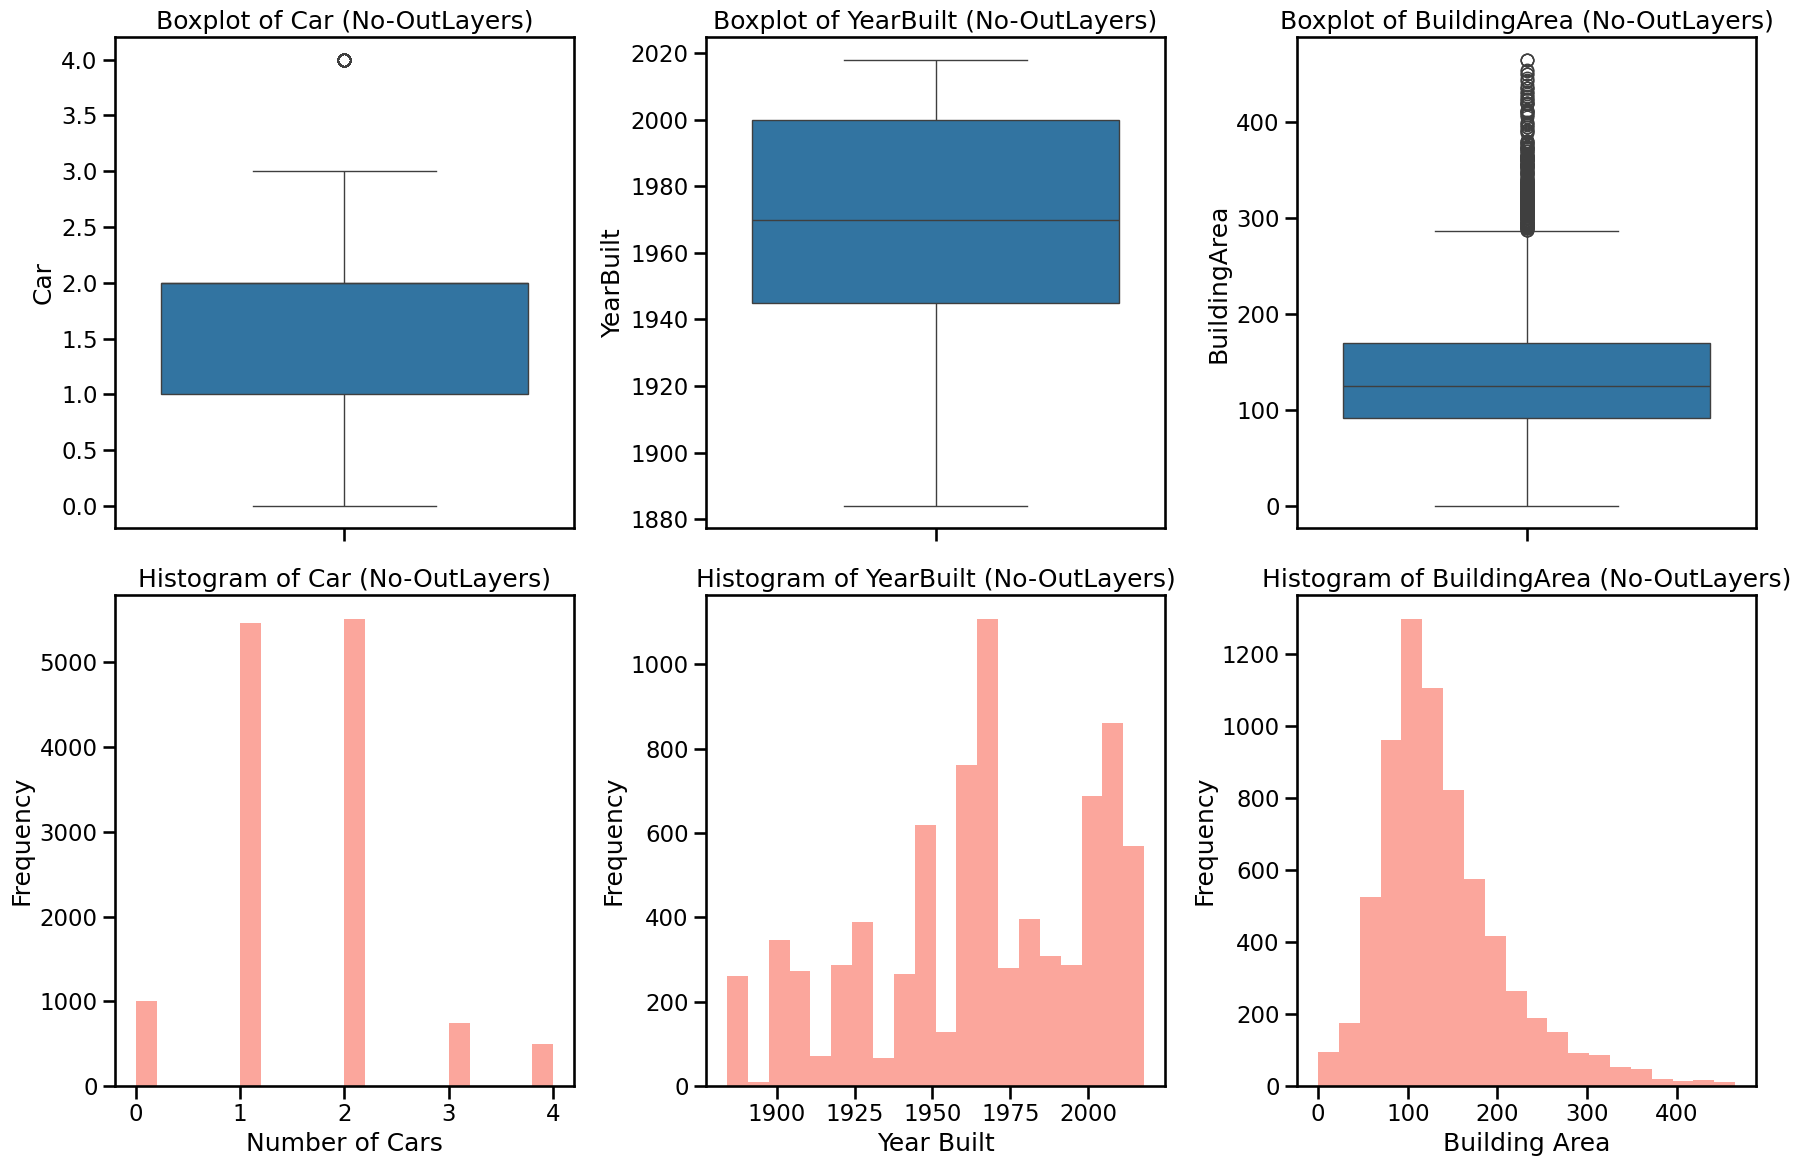

In [ ]:
plt.figure(figsize=(18, 12))

# Car
plt.subplot(2, 3, 1)
seaborn.boxplot(y=melb_df_2_2_reducido['Car'])
plt.title('Boxplot of Car (No-OutLayers)')

plt.subplot(2, 3, 4)
plt.hist(melb_df_2_2_reducido['Car'], bins=20, alpha=0.7, color='salmon')
plt.title('Histogram of Car (No-OutLayers)')
plt.xlabel('Number of Cars')
plt.ylabel('Frequency')


# YearBuilt
plt.subplot(2, 3, 2)
seaborn.boxplot(y=melb_df_2_2_reducido['YearBuilt'])
plt.title('Boxplot of YearBuilt (No-OutLayers)')

plt.subplot(2, 3, 5)
plt.hist(melb_df_2_2_reducido['YearBuilt'], bins=20, alpha=0.7, color='salmon')
plt.title('Histogram of YearBuilt (No-OutLayers)')
plt.xlabel('Year Built')
plt.ylabel('Frequency')

# BuildingArea
plt.subplot(2, 3, 3)
seaborn.boxplot(y=melb_df_2_2_reducido['BuildingArea'])
plt.title('Boxplot of BuildingArea (No-OutLayers)')

plt.subplot(2, 3, 6)
plt.hist(melb_df_2_2_reducido['BuildingArea'], bins=20, alpha=0.7, color='salmon')
plt.title('Histogram of BuildingArea (No-OutLayers)')
plt.xlabel('Building Area')
plt.ylabel('Frequency')

plt.tight_layout()
# ✅ Guardar como imagen (PNG, alta calidad)
plt.savefig("data_no_outlayers.png", dpi=300, bbox_inches='tight')
plt.show()

* Con este grafico confirmamos que:
  * Al eliminar valores extremos detectamos valores atípicos (outliers) con los boxplots.
  * Observar la distribución general con los histogramas, se acerca mas a la normal, .
  * Identificamos menos asimetria, mas que nada en los campos Year Built y Building Area.

Ahora si, hacemos la imputacion

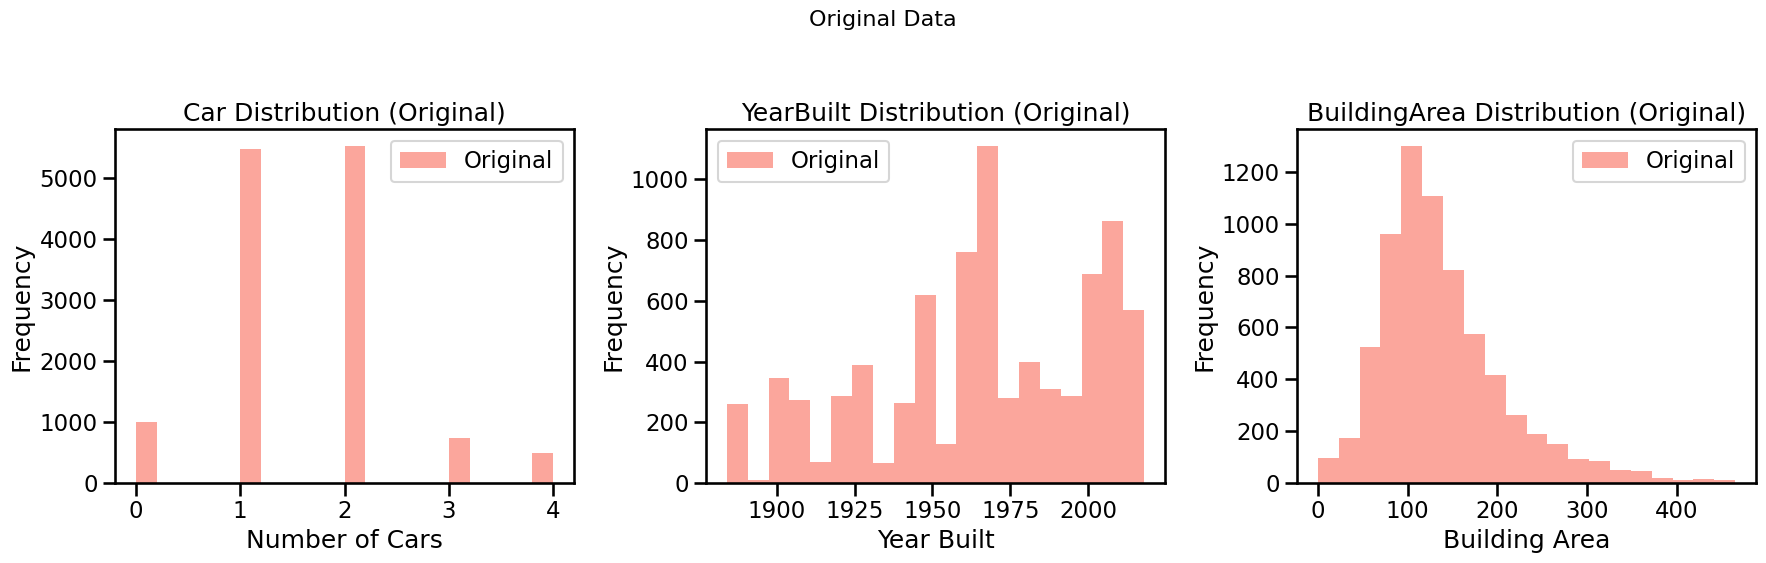

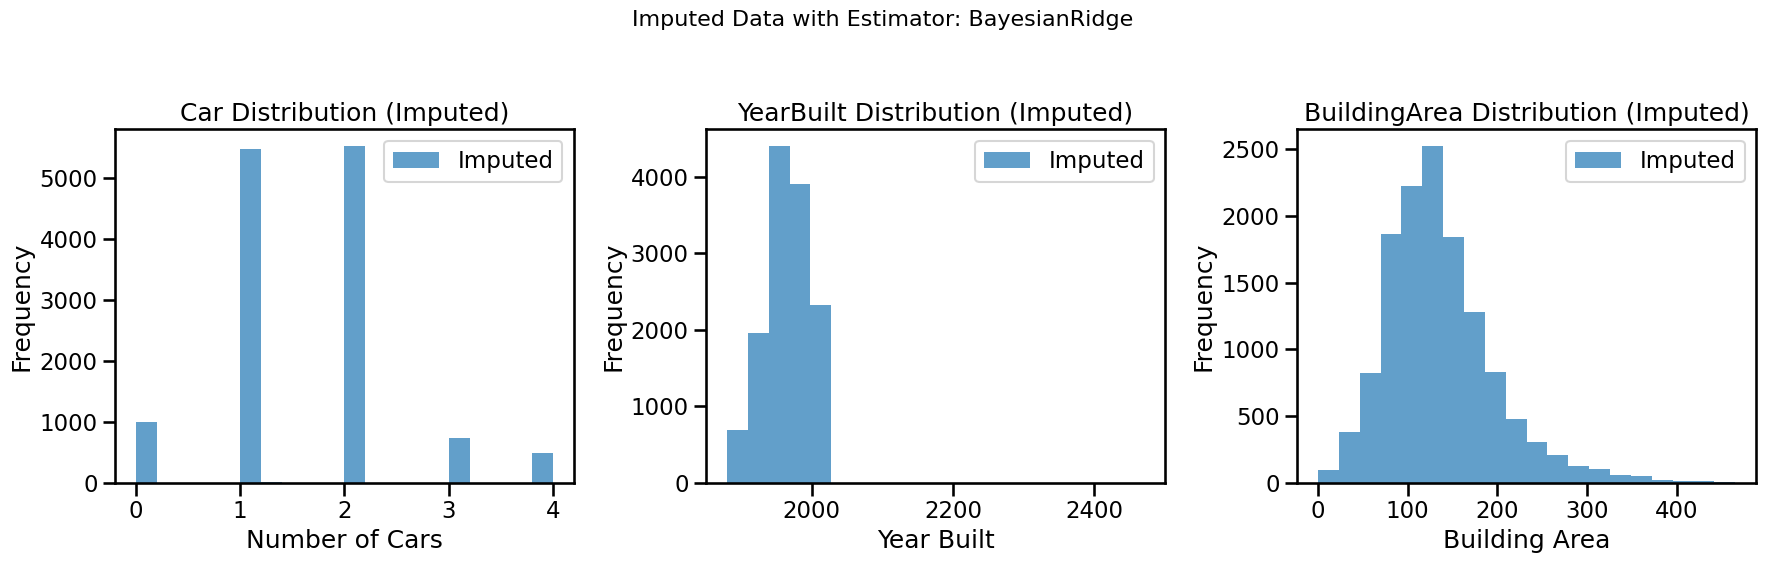

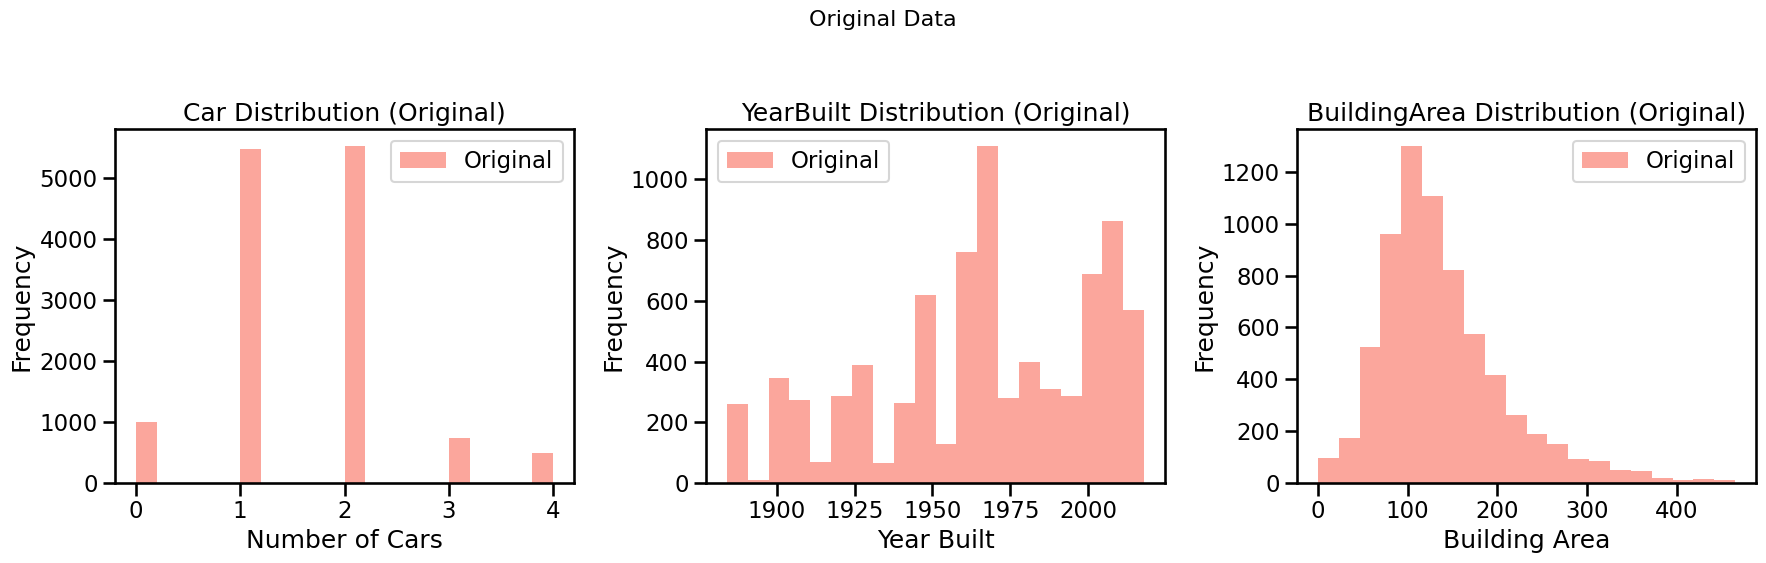

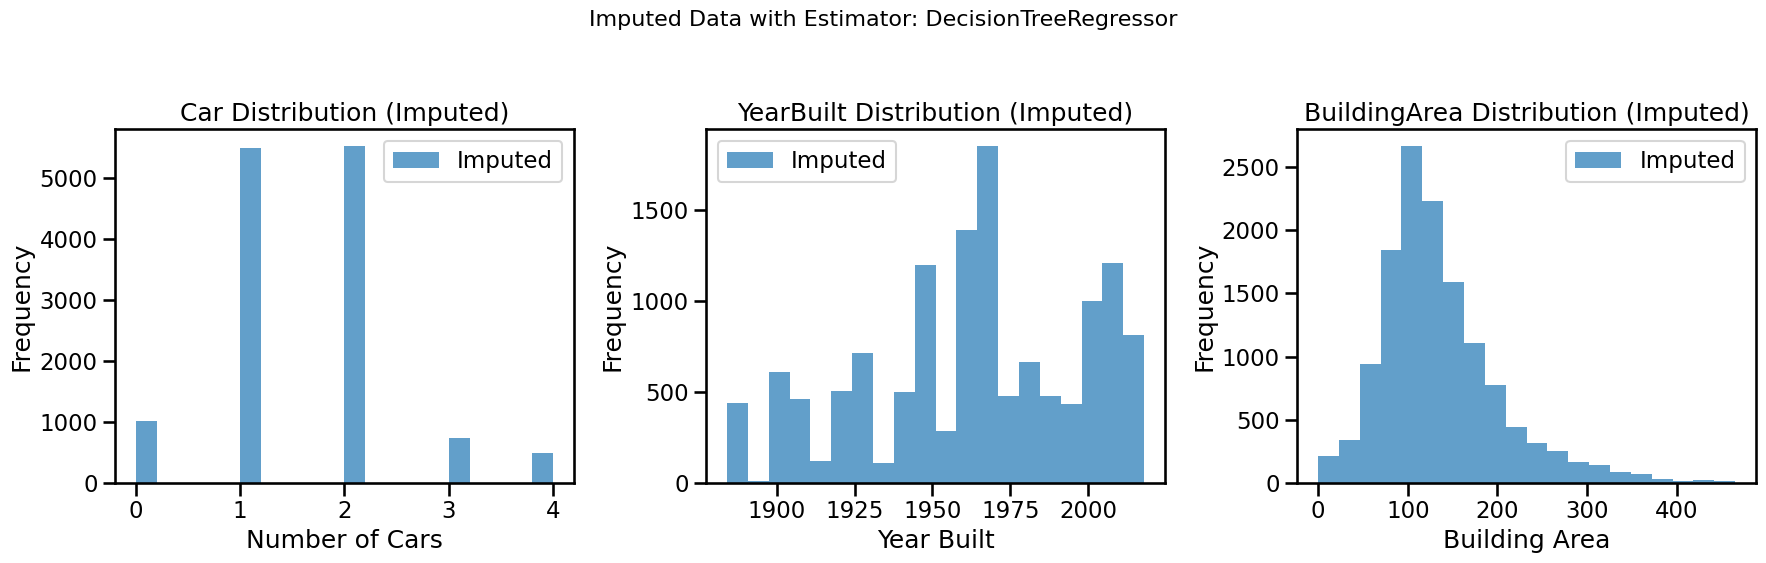

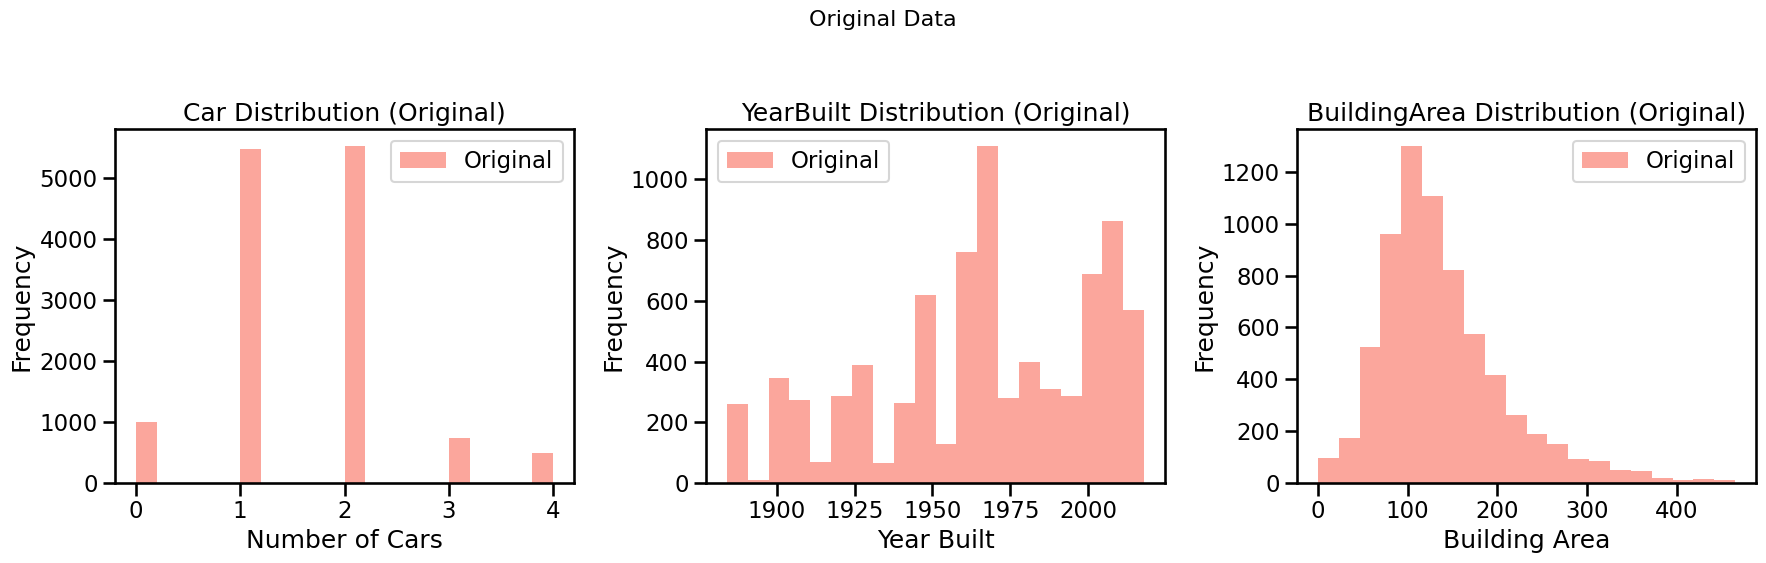

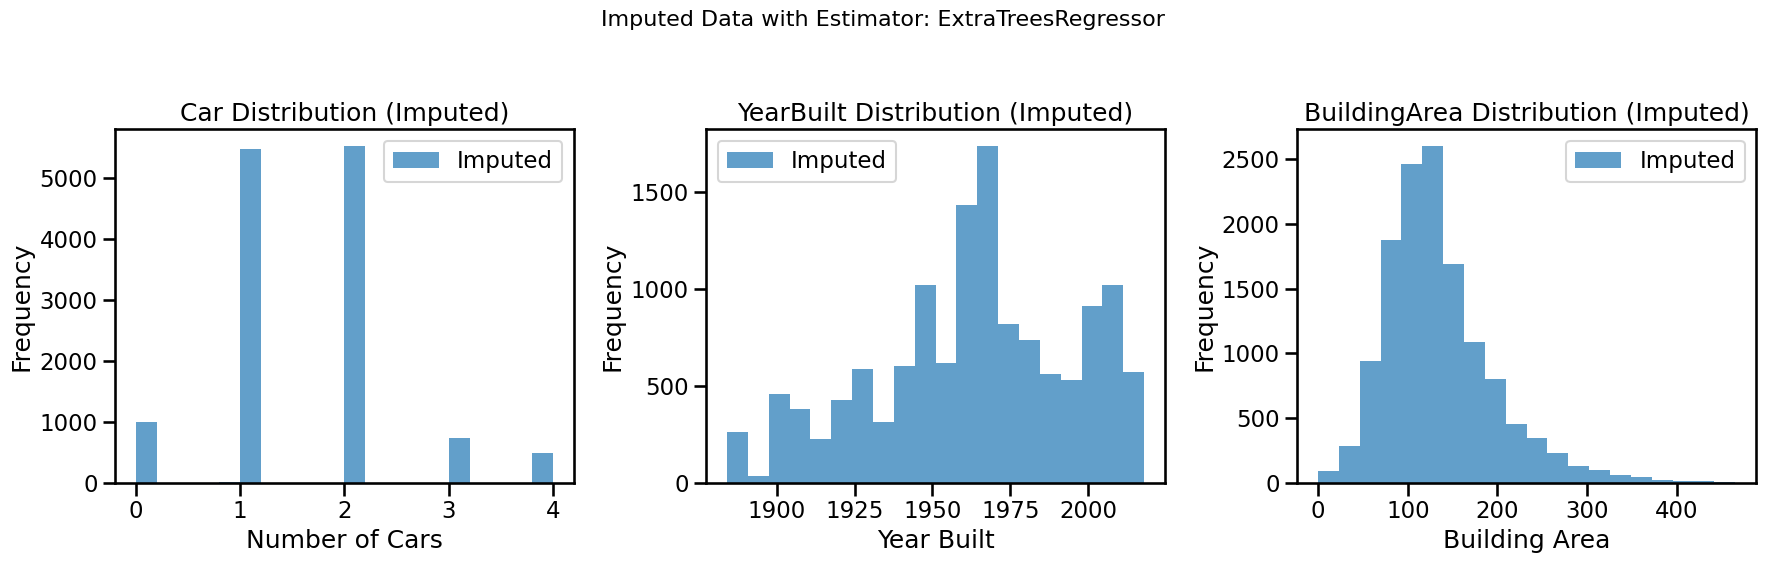

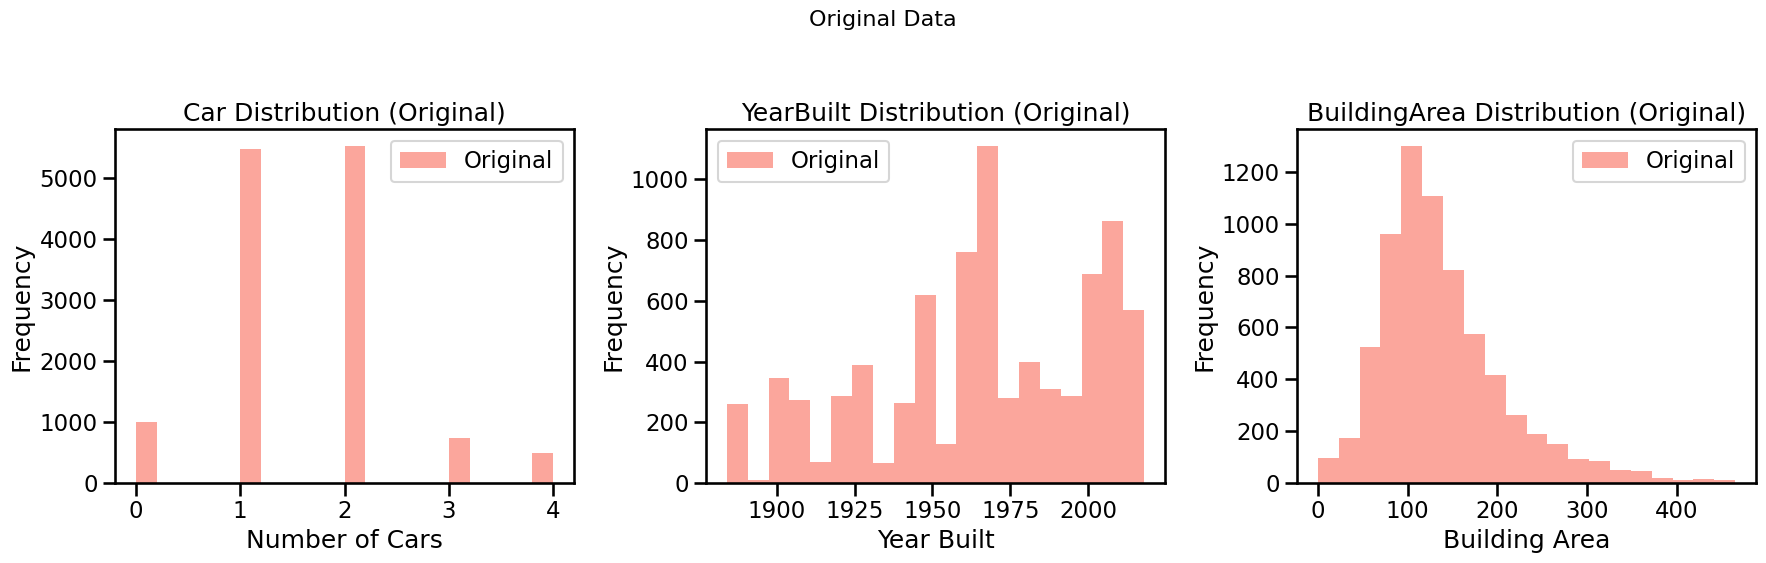

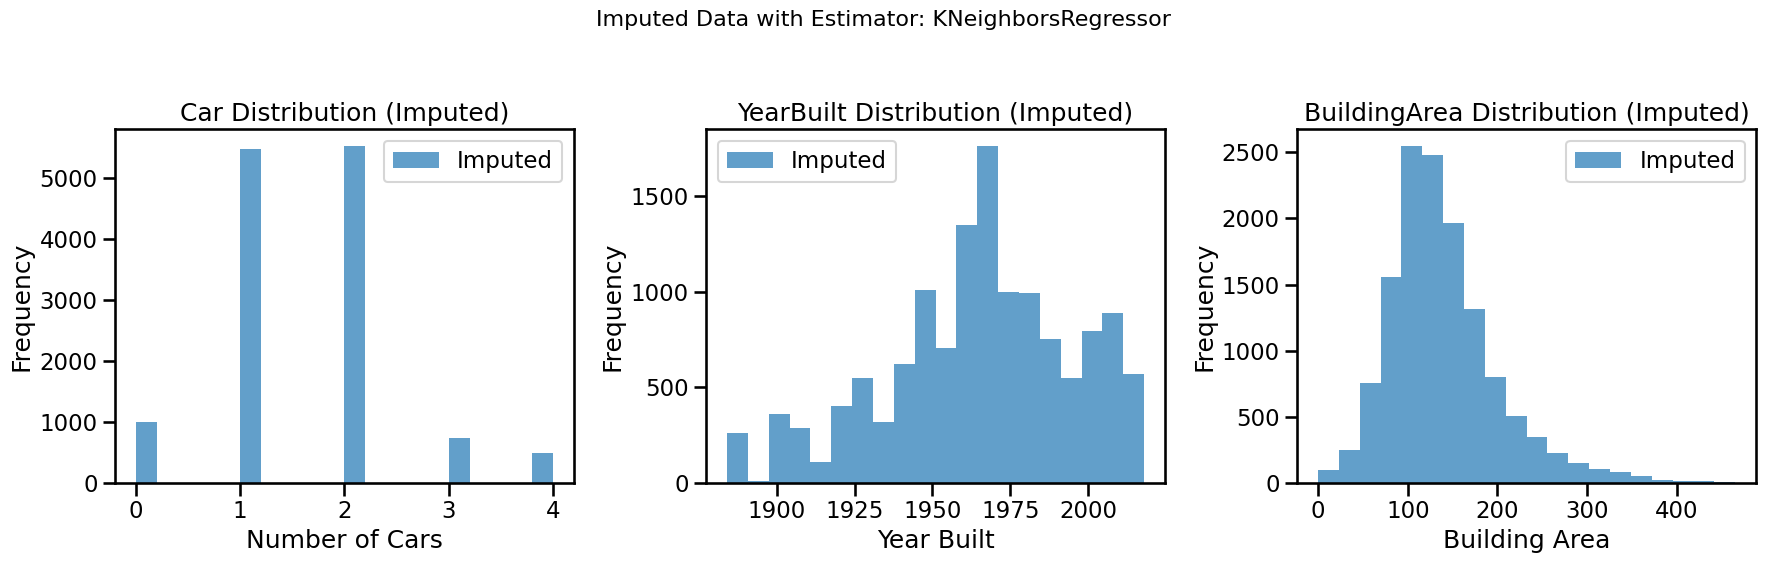

In [ ]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.tree import DecisionTreeRegressor

estimadores=[BayesianRidge, DecisionTreeRegressor, ExtraTreesRegressor, KNeighborsRegressor]
#estimadores=[KNeighborsRegressor]


# La imputacion se realiza para las columnas Car, YearBuilt, BuildingArea:
for algorithm in estimadores:
  melb_data_mice = melb_df_2_2_reducido.copy(deep=True)
  melb_data_mice = melb_data_mice.select_dtypes(include='number')
  mice_imputer = IterativeImputer(random_state=10, estimator=algorithm())

  result = mice_imputer.fit_transform(melb_data_mice)
  melb_data_mice[['Car', 'YearBuilt', 'BuildingArea']] = result[:, melb_data_mice.columns.get_indexer(['Car', 'YearBuilt', 'BuildingArea'])]

  # Plot the histograms for original data
  fig_original, axes_original = plt.subplots(1, 3, figsize=(18, 6))

  axes_original[0].hist(melb_df_2_2_reducido['Car'], bins=20, alpha=0.7, label='Original',color='salmon')
  axes_original[0].set_title('Car Distribution (Original)')
  axes_original[0].set_xlabel('Number of Cars')
  axes_original[0].set_ylabel('Frequency')
  axes_original[0].legend()

  axes_original[1].hist(melb_df_2_2_reducido['YearBuilt'], bins=20, alpha=0.7, label='Original',color='salmon')
  axes_original[1].set_title('YearBuilt Distribution (Original)')
  axes_original[1].set_xlabel('Year Built')
  axes_original[1].set_ylabel('Frequency')
  axes_original[1].legend()

  axes_original[2].hist(melb_df_2_2_reducido['BuildingArea'], bins=20, alpha=0.7, label='Original',color='salmon')
  axes_original[2].set_title('BuildingArea Distribution (Original)')
  axes_original[2].set_xlabel('Building Area')
  axes_original[2].set_ylabel('Frequency')
  axes_original[2].legend()

  fig_original.suptitle(f'Original Data', fontsize=16)
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
  plt.show()


  # Plot the histograms for imputed data
  fig_imputed, axes_imputed = plt.subplots(1, 3, figsize=(18, 6))

  axes_imputed[0].hist(melb_data_mice['Car'], bins=20, alpha=0.7, label='Imputed')
  axes_imputed[0].set_title('Car Distribution (Imputed)')
  axes_imputed[0].set_xlabel('Number of Cars')
  axes_imputed[0].set_ylabel('Frequency')
  axes_imputed[0].legend()

  axes_imputed[1].hist(melb_data_mice['YearBuilt'], bins=20, alpha=0.7, label='Imputed')
  axes_imputed[1].set_title('YearBuilt Distribution (Imputed)')
  axes_imputed[1].set_xlabel('Year Built')
  axes_imputed[1].set_ylabel('Frequency')
  axes_imputed[1].legend()

  axes_imputed[2].hist(melb_data_mice['BuildingArea'], bins=20, alpha=0.7, label='Imputed')
  axes_imputed[2].set_title('BuildingArea Distribution (Imputed)')
  axes_imputed[2].set_xlabel('Building Area')
  axes_imputed[2].set_ylabel('Frequency')
  axes_imputed[2].legend()

  fig_imputed.suptitle(f'Imputed Data with Estimator: {algorithm.__name__}', fontsize=16)
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
  plt.show()


* Objetivo de esta imputación
  * Imputar valores faltantes en las columnas 'Car', 'YearBuilt' y 'BuildingArea' usando el algoritmo IterativeImputer con diferentes estimadores (regresores), y comparar visualmente cómo cambia la distribución de los datos antes y después de la imputación.
* Objetivo del histograma
  * Comparar visualmente cómo cambió la distribución, si suavizó picos, rellenó huecos, o cambió la forma.
* Visualizamos que la imputación respeta la forma general, con los valores normalizamos, haciendo que los datos se visualicen de manera mas simetrica, donde los valores se suavizan.

### ¿Es necesario estandarizar o escalar?
* Entendemos que depende del estimador que utilicemos, para algunos como el BayesianRidge y KNeighborsRegressor es importante poder escalar, puntualmente con KNeighborsRegressor es obligatorio, mientras que con DecisionTreeRegressor y ExtraTreesRegressor, no es necesario.

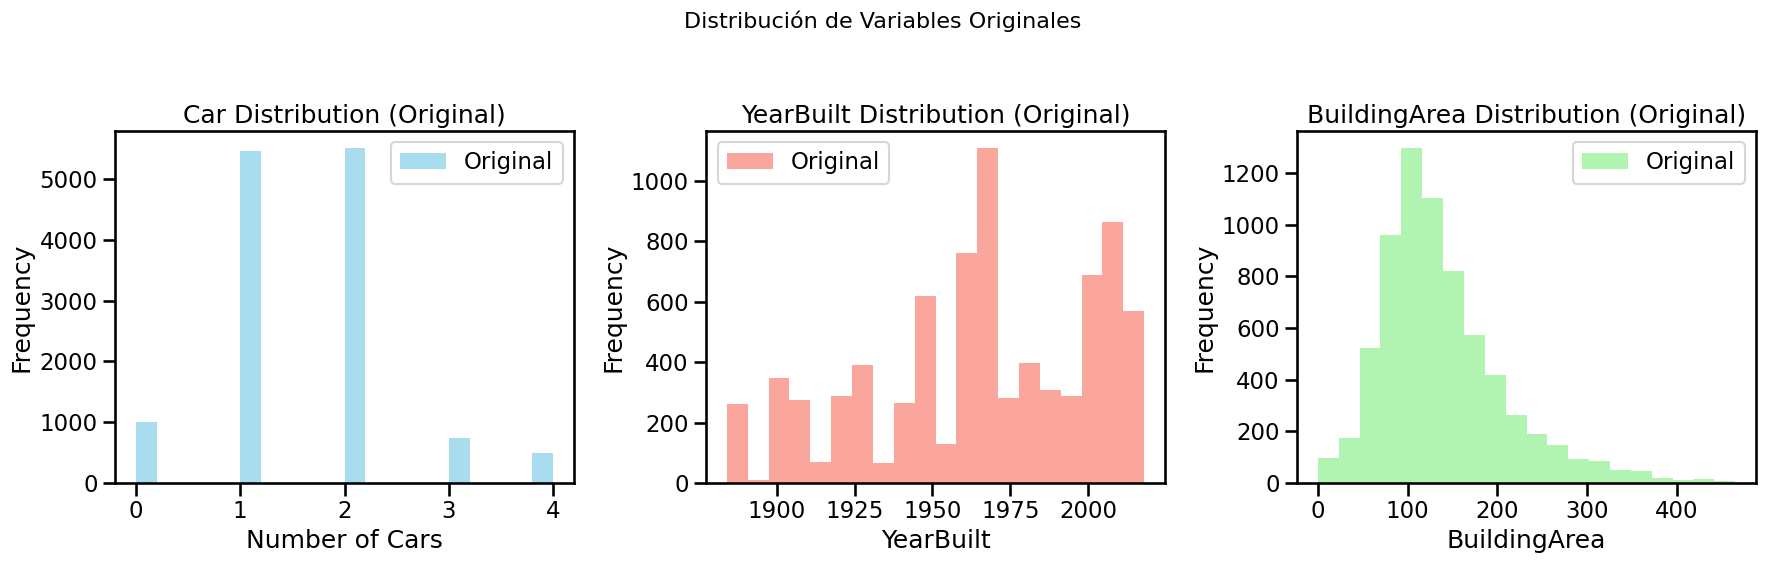

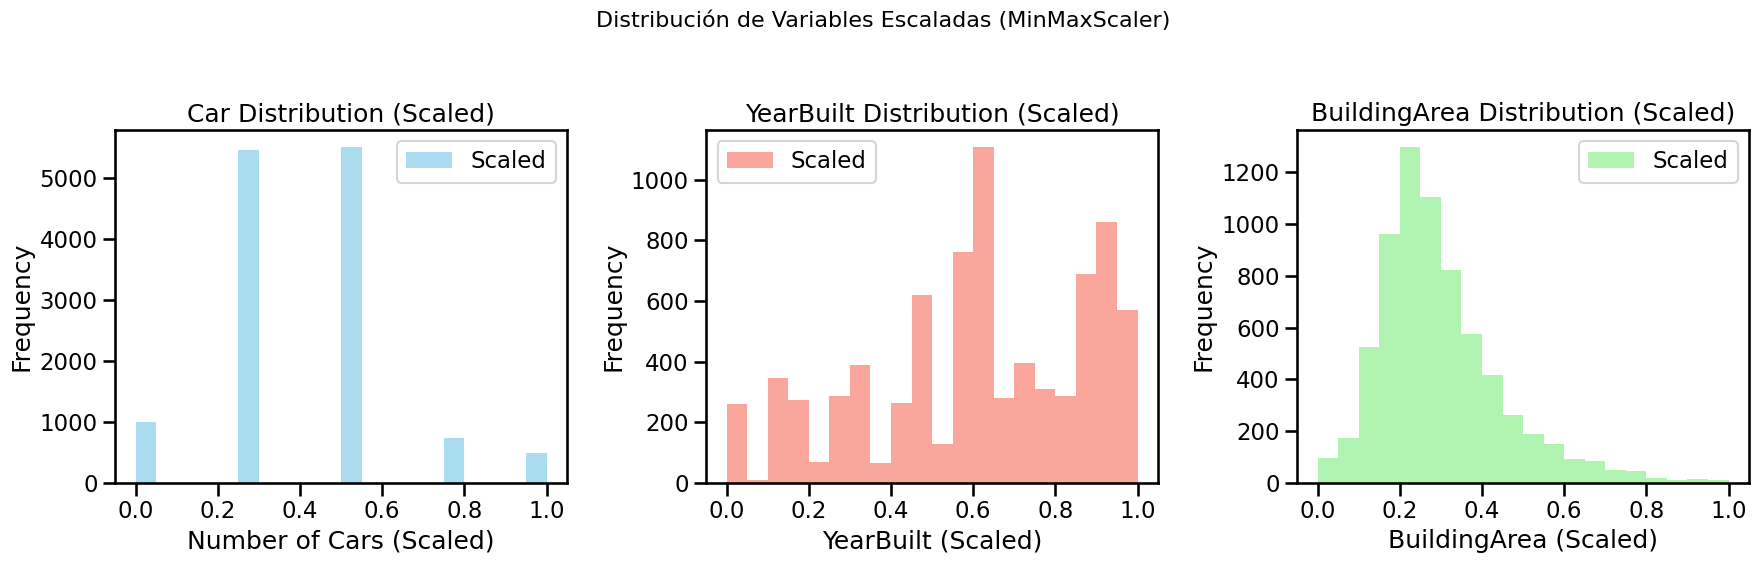

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Datos originales
melb_df_2_2_reducido

# Crear un objeto MinMaxScaler
scaler = MinMaxScaler()

# Ajustar y transformar los datos
melb_df_2_2_reducidoScaled = scaler.fit_transform(melb_df_2_2_reducido)

# Convertir a Data Frame
melb_df_2_2_reducidoScaled = pd.DataFrame(melb_df_2_2_reducidoScaled, columns=melb_df_2_2_reducido.columns)


# Graficos para los datos originales
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot Car histogram (Original)
axes[0].hist(melb_df_2_2_reducido['Car'], bins=20, alpha=0.7, label='Original', color='skyblue')
axes[0].set_title('Car Distribution (Original)')
axes[0].set_xlabel('Number of Cars')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Plot YearBuilt histogram (Original)
axes[1].hist(melb_df_2_2_reducido['YearBuilt'], bins=20, alpha=0.7, label='Original', color='salmon')
axes[1].set_title('YearBuilt Distribution (Original)')
axes[1].set_xlabel('YearBuilt')
axes[1].set_ylabel('Frequency')
axes[1].legend()

# Plot BuildingArea histogram (Original)
axes[2].hist(melb_df_2_2_reducido['BuildingArea'], bins=20, alpha=0.7, label='Original', color='lightgreen')
axes[2].set_title('BuildingArea Distribution (Original)')
axes[2].set_xlabel('BuildingArea')
axes[2].set_ylabel('Frequency')
axes[2].legend()

fig.suptitle('Distribución de Variables Originales', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


# Graficos para los datos escalados
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot Car histogram (Scaled)
axes[0].hist(melb_df_2_2_reducidoScaled['Car'], bins=20, alpha=0.7, label='Scaled', color='skyblue')
axes[0].set_title('Car Distribution (Scaled)')
axes[0].set_xlabel('Number of Cars (Scaled)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Plot YearBuilt histogram (Scaled)
axes[1].hist(melb_df_2_2_reducidoScaled['YearBuilt'], bins=20, alpha=0.7, label='Scaled', color='salmon')
axes[1].set_title('YearBuilt Distribution (Scaled)')
axes[1].set_xlabel('YearBuilt (Scaled)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

# Plot BuildingArea histogram (Scaled)
axes[2].hist(melb_df_2_2_reducidoScaled['BuildingArea'], bins=20, alpha=0.7, label='Scaled', color='lightgreen')
axes[2].set_title('BuildingArea Distribution (Scaled)')
axes[2].set_xlabel('BuildingArea (Scaled)')
axes[2].set_ylabel('Frequency')
axes[2].legend()

fig.suptitle('Distribución de Variables Escaladas (MinMaxScaler)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Realizamos nuevamente la imputacion, pero ahora con los datos escalados

/usr/local/lib/python3.11/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


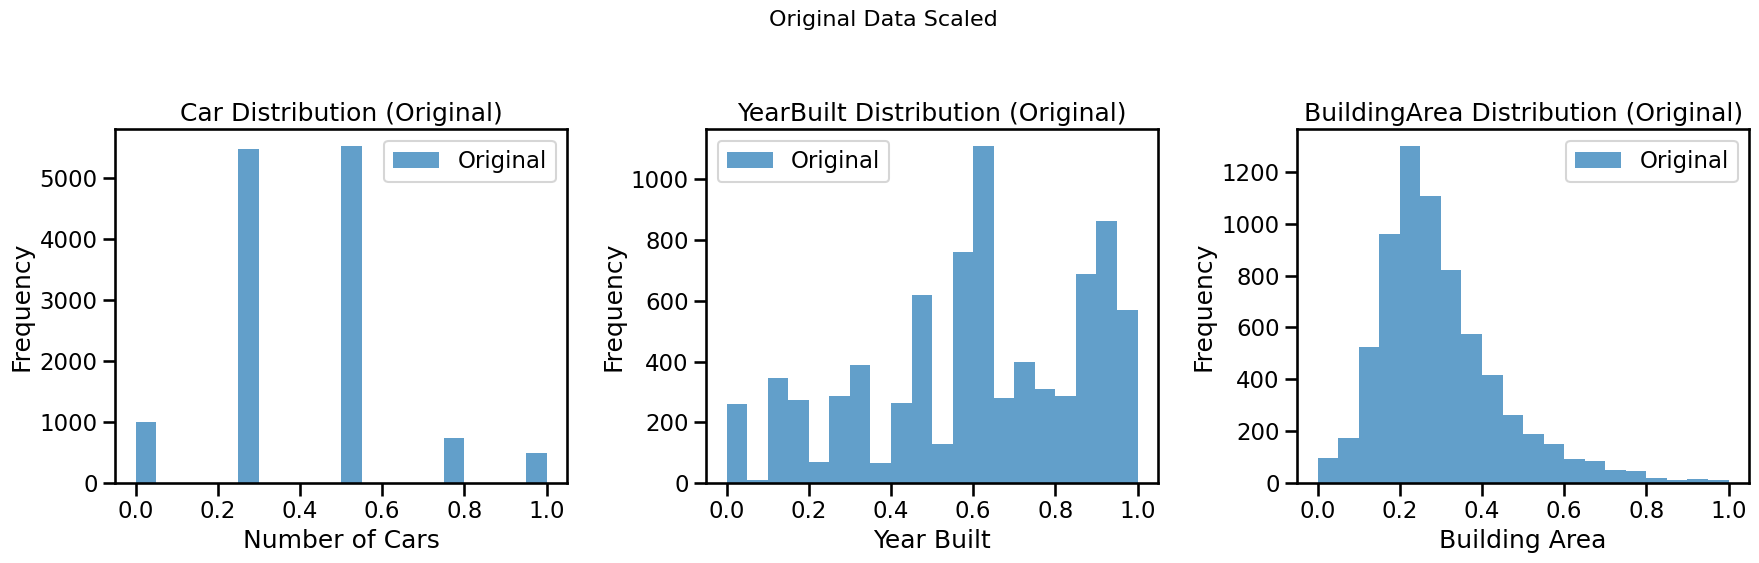

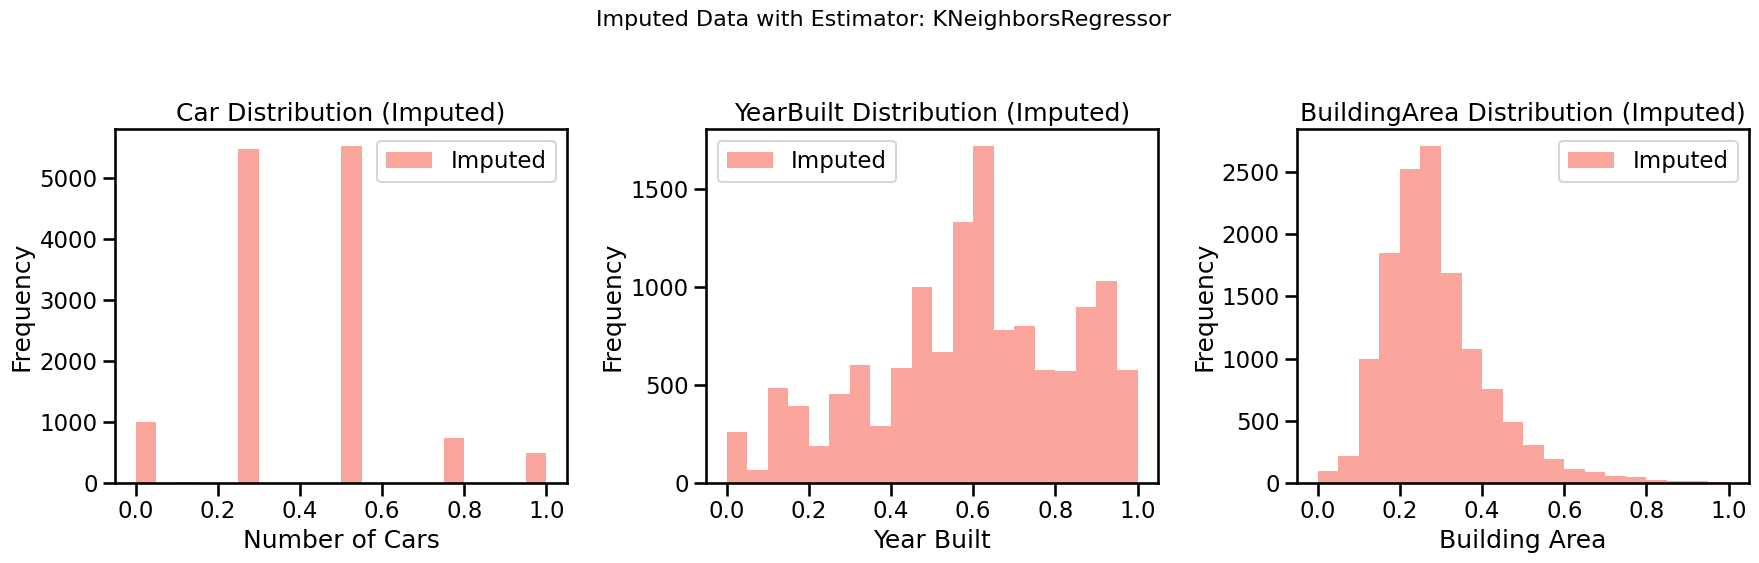

In [ ]:
#estimadores=[BayesianRidge, DecisionTreeRegressor, ExtraTreesRegressor, KNeighborsRegressor]
estimadores=[KNeighborsRegressor]


# La imputacion se realiza para las columnas Car, YearBuilt, BuildingArea:
for algorithm in estimadores:
  melb_data_mice = melb_df_2_2_reducidoScaled.copy(deep=True)
  melb_data_mice = melb_data_mice.select_dtypes(include='number')
  mice_imputer = IterativeImputer(random_state=10, estimator=algorithm())

  result = mice_imputer.fit_transform(melb_data_mice)
  melb_data_mice[['Car', 'YearBuilt', 'BuildingArea']] = result[:, melb_data_mice.columns.get_indexer(['Car', 'YearBuilt', 'BuildingArea'])]

  # Plot the histograms for original data
  fig_original, axes_original = plt.subplots(1, 3, figsize=(18, 6))

  axes_original[0].hist(melb_df_2_2_reducidoScaled['Car'], bins=20, alpha=0.7, label='Original')
  axes_original[0].set_title('Car Distribution (Original)')
  axes_original[0].set_xlabel('Number of Cars')
  axes_original[0].set_ylabel('Frequency')
  axes_original[0].legend()

  axes_original[1].hist(melb_df_2_2_reducidoScaled['YearBuilt'], bins=20, alpha=0.7, label='Original')
  axes_original[1].set_title('YearBuilt Distribution (Original)')
  axes_original[1].set_xlabel('Year Built')
  axes_original[1].set_ylabel('Frequency')
  axes_original[1].legend()

  axes_original[2].hist(melb_df_2_2_reducidoScaled['BuildingArea'], bins=20, alpha=0.7, label='Original')
  axes_original[2].set_title('BuildingArea Distribution (Original)')
  axes_original[2].set_xlabel('Building Area')
  axes_original[2].set_ylabel('Frequency')
  axes_original[2].legend()

  fig_original.suptitle(f'Original Data Scaled', fontsize=16)
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    # ✅ Guardar como imagen (PNG, alta calidad)
  plt.savefig("data_original_scaled.png", dpi=300, bbox_inches='tight')
  plt.show()


  # Plot the histograms for imputed data
  fig_imputed, axes_imputed = plt.subplots(1, 3, figsize=(18, 6))

  axes_imputed[0].hist(melb_data_mice['Car'], bins=20, alpha=0.7, label='Imputed',color='salmon')
  axes_imputed[0].set_title('Car Distribution (Imputed)')
  axes_imputed[0].set_xlabel('Number of Cars')
  axes_imputed[0].set_ylabel('Frequency')
  axes_imputed[0].legend()

  axes_imputed[1].hist(melb_data_mice['YearBuilt'], bins=20, alpha=0.7, label='Imputed',color='salmon')
  axes_imputed[1].set_title('YearBuilt Distribution (Imputed)')
  axes_imputed[1].set_xlabel('Year Built')
  axes_imputed[1].set_ylabel('Frequency')
  axes_imputed[1].legend()

  axes_imputed[2].hist(melb_data_mice['BuildingArea'], bins=20, alpha=0.7, label='Imputed',color='salmon')
  axes_imputed[2].set_title('BuildingArea Distribution (Imputed)')
  axes_imputed[2].set_xlabel('Building Area')
  axes_imputed[2].set_ylabel('Frequency')
  axes_imputed[2].legend()

  fig_imputed.suptitle(f'Imputed Data with Estimator: {algorithm.__name__}', fontsize=16)
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
  # ✅ Guardar como imagen (PNG, alta calidad)
  plt.savefig("data_imputed_KNeighborsRegressor.png", dpi=300, bbox_inches='tight')
  plt.show()

# Ejercicio 3: Reducción de dimensionalidad.

Utilizando la matriz obtenida en el ejercicio anterior:
1. Aplique `PCA` para obtener $n$ componentes principales de la matriz, donde `n = min(20, X.shape[0])`. ¿Es necesario estandarizar o escalar los datos?
2. Seleccione las primeras $2$ columnas de la matriz transformada para agregar como nuevas características al conjunto de datos.

## 3.1) Aplique `PCA` para obtener $n$ componentes principales de la matriz, donde `n = min(20, X.shape[0])`. ¿Es necesario estandarizar o escalar los datos?

In [ ]:
# Se genera el Data Frame 'melb_df_3_1' para el Ejercicio 3.1

melb_df_3_1_reducido=melb_data_mice.copy()
# Solo las columnas 'Type','Method'y 'Regionname' fueron codificadas.
# Las columnas `YearBuilt` y `BuildingArea` fueron imputadas mediante -KNeighborsRegressor-.

print(f"El Data Frame 'melb_df_3_1_reducido' tiene {melb_df_2_1_reducido.shape[0]} filas y {melb_df_2_1_reducido.shape[1]} columnas. Solo las columnas 'Type','Method'y 'Regionname' fueron codificadas. Las columnas 'Car', `YearBuilt` y `BuildingArea` fueron imputadas mediante 'KNeighborsRegressor'.")



El Data Frame 'melb_df_3_1_reducido' tiene 13580 filas y 29 columnas. Solo las columnas 'Type','Method'y 'Regionname' fueron codificadas. Las columnas 'Car', `YearBuilt` y `BuildingArea` fueron imputadas mediante 'KNeighborsRegressor'.


Al entrenar la instancia de la clase PCA, sklearn se encarga de centrar los datos restandoles la media. Sin embargo, es recomendable también estandarizar o al menos escalar la matriz original para asegurar de que todas las variables estén en las mismas unidades y ninguna tenga un peso demasiado grande.

In [ ]:
# TODO Here we have to pre-process the matrix before applying PCA
melb_array_3_1_reducido = np.asarray(melb_df_3_1_reducido)

scaler = MinMaxScaler(feature_range=(-1, 1))

melb_array_3_1_reducidoScaled = scaler.fit_transform(melb_array_3_1_reducido)
np.max(melb_array_3_1_reducidoScaled), np.min(melb_array_3_1_reducidoScaled)


(np.float64(1.0), np.float64(-1.0))

In [ ]:
X=melb_array_3_1_reducidoScaled


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=min(20, X.shape[0]))

pca.fit(X)
print("Principal components")
print(pca.components_)
print("Explained variance: ")
print(pca.explained_variance_)
print("Explained variance ratio")
print(pca.explained_variance_ratio_)


Principal components
[[ 7.89824975e-02  2.44171716e-02  4.59443273e-02 -3.02479929e-02
   3.45522576e-02  1.75128524e-02  8.00900283e-02  2.18875176e-04
   5.08523660e-02 -2.10720851e-02 -2.46796763e-02  6.26493020e-01
  -8.90077129e-02 -5.37485307e-01 -6.07117885e-02  1.85964478e-01
  -2.23902384e-03 -4.83562208e-02 -7.46574448e-02  6.82859040e-02
   2.51708264e-03  1.48870738e-01  2.93632220e-03  2.22642127e-02
  -4.09499068e-01  1.62088499e-01  2.53630992e-03 -1.26970838e-01
   7.52809469e-02]
 [ 5.05139581e-02  6.04157391e-02  3.13462408e-02  6.25624101e-02
   2.20262815e-02  3.34529483e-02  7.02464963e-02  3.39616548e-05
  -9.62937270e-02  4.43016204e-02 -6.17716171e-02  2.40621647e-01
  -4.34281080e-02 -1.97193539e-01 -4.10931960e-02  2.64922200e-01
  -5.73232470e-04 -1.92713525e-01 -3.05422461e-02  2.31669047e-02
   9.55460422e-04 -6.00681547e-01  7.02119398e-04  1.29983092e-02
   6.16530908e-01 -5.46963471e-02  1.02419213e-03 -8.98276959e-02
   7.74616402e-02]
 [-3.92494171e-02

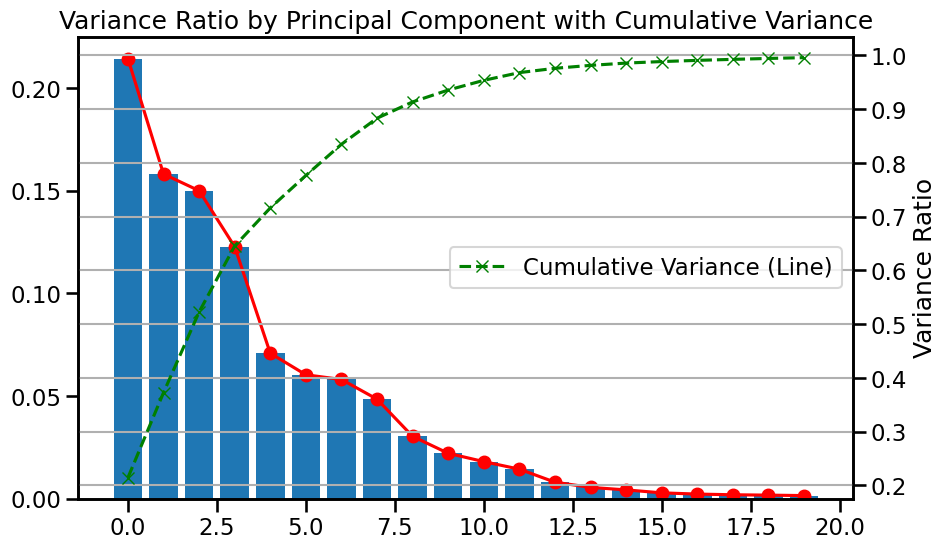

In [ ]:
# Get the explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_

# Create an array of indices for the x-axis
x_positions = range(len(explained_variance_ratio))

# Plot the bar chart and line chart in the same figure
plt.figure(figsize=(10, 6))

# Bar chart
plt.bar(x_positions, explained_variance_ratio, label='Variance Ratio (Bar)')

# Line chart
plt.plot(x_positions, explained_variance_ratio, marker='o', linestyle='-', color='red', label='Variance Ratio (Line)')

# Calculate cumulative sum
cumulative_variance = np.cumsum(explained_variance_ratio)

# Create a secondary y-axis for cumulative variance
ax2 = plt.gca().twinx() # Get current axes and create a twin
ax2.plot(x_positions, cumulative_variance, marker='x', linestyle='--', color='green', label='Cumulative Variance (Line)')
ax2.set_ylabel('Cumulative Variance Ratio')
ax2.legend(loc='center right')

plt.title('Variance Ratio by Principal Component with Cumulative Variance')
plt.xlabel('Principal Component Index')
plt.ylabel('Variance Ratio')
plt.grid(True)
# ✅ Guardar como imagen (PNG, alta calidad)
plt.savefig("pca_variance_plot.png", dpi=300, bbox_inches='tight')
plt.show()

Se puede mencionar que a partir de la componente principal numero 8 se puede desestimar, ya que apartir de ahi el aporte de las componentes no es significativo y el acumulado de la Varianza es de aproximadamente el 90%.

In [ ]:
# Se realiza la transformacion
X_projected = pca.transform(X)
X_projected.shape

(13276, 20)


## 3.2) Seleccione las primeras $2$ columnas de la matriz transformada para agregar como nuevas características al conjunto de datos.

In [ ]:
# Se genera el Data Frame 'melb_df_3_2' para el Ejercicio 3.2

melb_df_3_2_reducido=melb_data_mice.copy() # solo las columnas 'Type','Method'y 'Regionname' fueron codificadas. Las columnas `YearBuilt` y `BuildingArea` fueron imputadas.
print(f"El Data Frame 'melb_df_3_2_reducido' tiene {melb_df_2_1_reducido.shape[0]} filas y {melb_df_2_1_reducido.shape[1]} columnas. Solo las columnas 'Type','Method'y 'Regionname' fueron codificadas. Las columnas `YearBuilt` y `BuildingArea` fueron imputadas.")


El Data Frame 'melb_df_3_2_reducido' tiene 13580 filas y 29 columnas. Solo las columnas 'Type','Method'y 'Regionname' fueron codificadas. Las columnas `YearBuilt` y `BuildingArea` fueron imputadas.


Se extrae de la matriz transformada X_projected, las primeras 2 columnas

In [ ]:
melb_df_3_2_reducido_pca=melb_df_3_2_reducido.copy()
melb_df_3_2_reducido_pca[['pca1_scaled', 'pca2_scaled']] = X_projected[:,:2]
melb_df_3_2_reducido_pca.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13276 entries, 0 to 13275
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Rooms                                  13276 non-null  float64
 1   Price                                  13276 non-null  float64
 2   Distance                               13276 non-null  float64
 3   Postcode                               13276 non-null  float64
 4   Bedroom2                               13276 non-null  float64
 5   Bathroom                               13276 non-null  float64
 6   Car                                    13276 non-null  float64
 7   Landsize                               13276 non-null  float64
 8   Lattitude                              13276 non-null  float64
 9   Longtitude                             13276 non-null  float64
 10  Propertycount                          13276 non-null  float64
 11  Ty

In [ ]:
melb_df_3_2_reducido_pca

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,Lattitude,Longtitude,...,Regionname_Northern Metropolitan,Regionname_Northern Victoria,Regionname_South-Eastern Metropolitan,Regionname_Southern Metropolitan,Regionname_Western Metropolitan,Regionname_Western Victoria,YearBuilt,BuildingArea,pca1_scaled,pca2_scaled
0,0.111111,0.156478,0.052743,0.068577,0.10,0.125,0.25,0.000466,0.494755,0.517651,...,1.0,0.0,0.0,0.0,0.0,0.0,0.253731,0.207742,1.248760,-0.760171
1,0.111111,0.106562,0.052743,0.068577,0.10,0.125,0.00,0.000360,0.484031,0.513083,...,1.0,0.0,0.0,0.0,0.0,0.0,0.119403,0.169892,1.233792,-0.781397
2,0.222222,0.154795,0.052743,0.068577,0.15,0.250,0.00,0.000309,0.482223,0.513997,...,1.0,0.0,0.0,0.0,0.0,0.0,0.119403,0.322581,0.815658,-1.644965
3,0.222222,0.085810,0.052743,0.068577,0.15,0.250,0.25,0.000217,0.498243,0.516281,...,1.0,0.0,0.0,0.0,0.0,0.0,0.265672,0.284731,0.786314,-1.349961
4,0.333333,0.169938,0.052743,0.068577,0.15,0.125,0.50,0.000277,0.484936,0.513723,...,1.0,0.0,0.0,0.0,0.0,0.0,0.970149,0.305376,0.638716,-1.401737
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13271,0.222222,0.055749,0.348101,0.050154,0.15,0.250,0.50,0.000591,0.650345,0.422177,...,1.0,0.0,0.0,0.0,0.0,0.0,0.644776,0.282581,1.272902,-0.787381
13272,0.333333,0.130118,0.352321,0.153531,0.20,0.250,0.50,0.001506,0.357781,0.672246,...,0.0,0.0,1.0,0.0,0.0,0.0,0.723881,0.411183,0.986100,0.531415
13273,0.222222,0.106113,0.143460,0.016377,0.15,0.250,0.50,0.000769,0.417664,0.408601,...,0.0,0.0,0.0,0.0,1.0,0.0,0.828358,0.286022,0.738193,-0.633040
13274,0.222222,0.121705,0.143460,0.016377,0.15,0.250,1.00,0.001007,0.426100,0.416221,...,0.0,0.0,0.0,0.0,1.0,0.0,0.843284,0.419355,1.304507,0.371387


<Axes: xlabel='pca1_scaled', ylabel='pca2_scaled'>

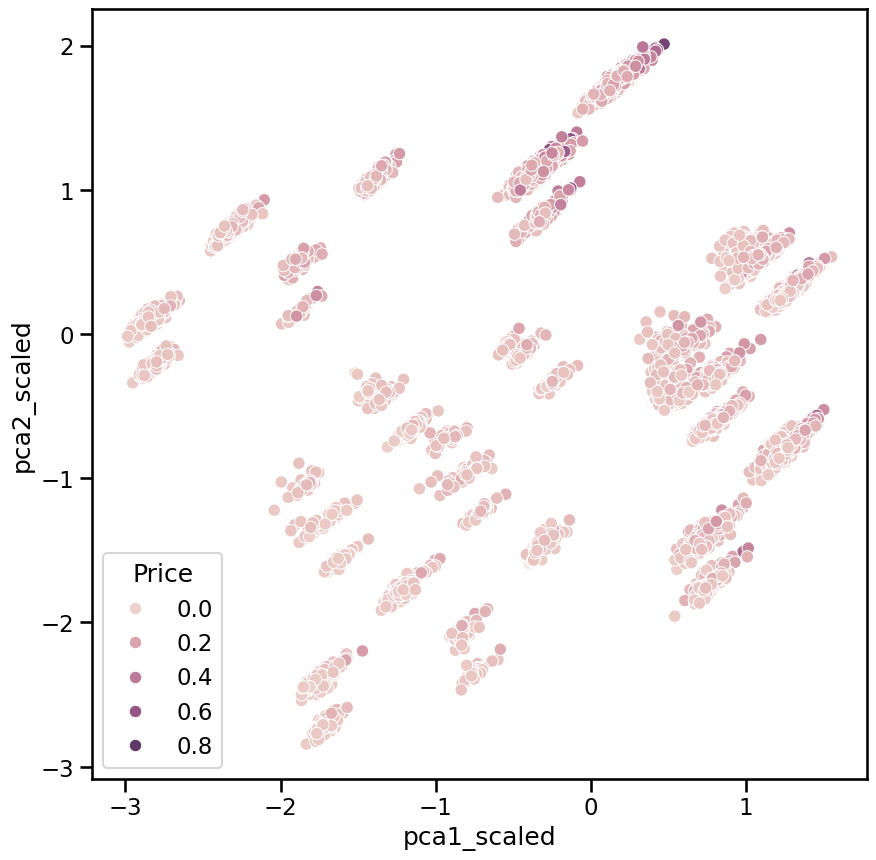

In [ ]:
data = melb_df_3_2_reducido_pca
fig = plt.figure(figsize=(10, 10))
seaborn.scatterplot(data=data, x='pca1_scaled', y='pca2_scaled',
                    hue='Price')  # 'Landsize' 'Price' 'YearBuilt'

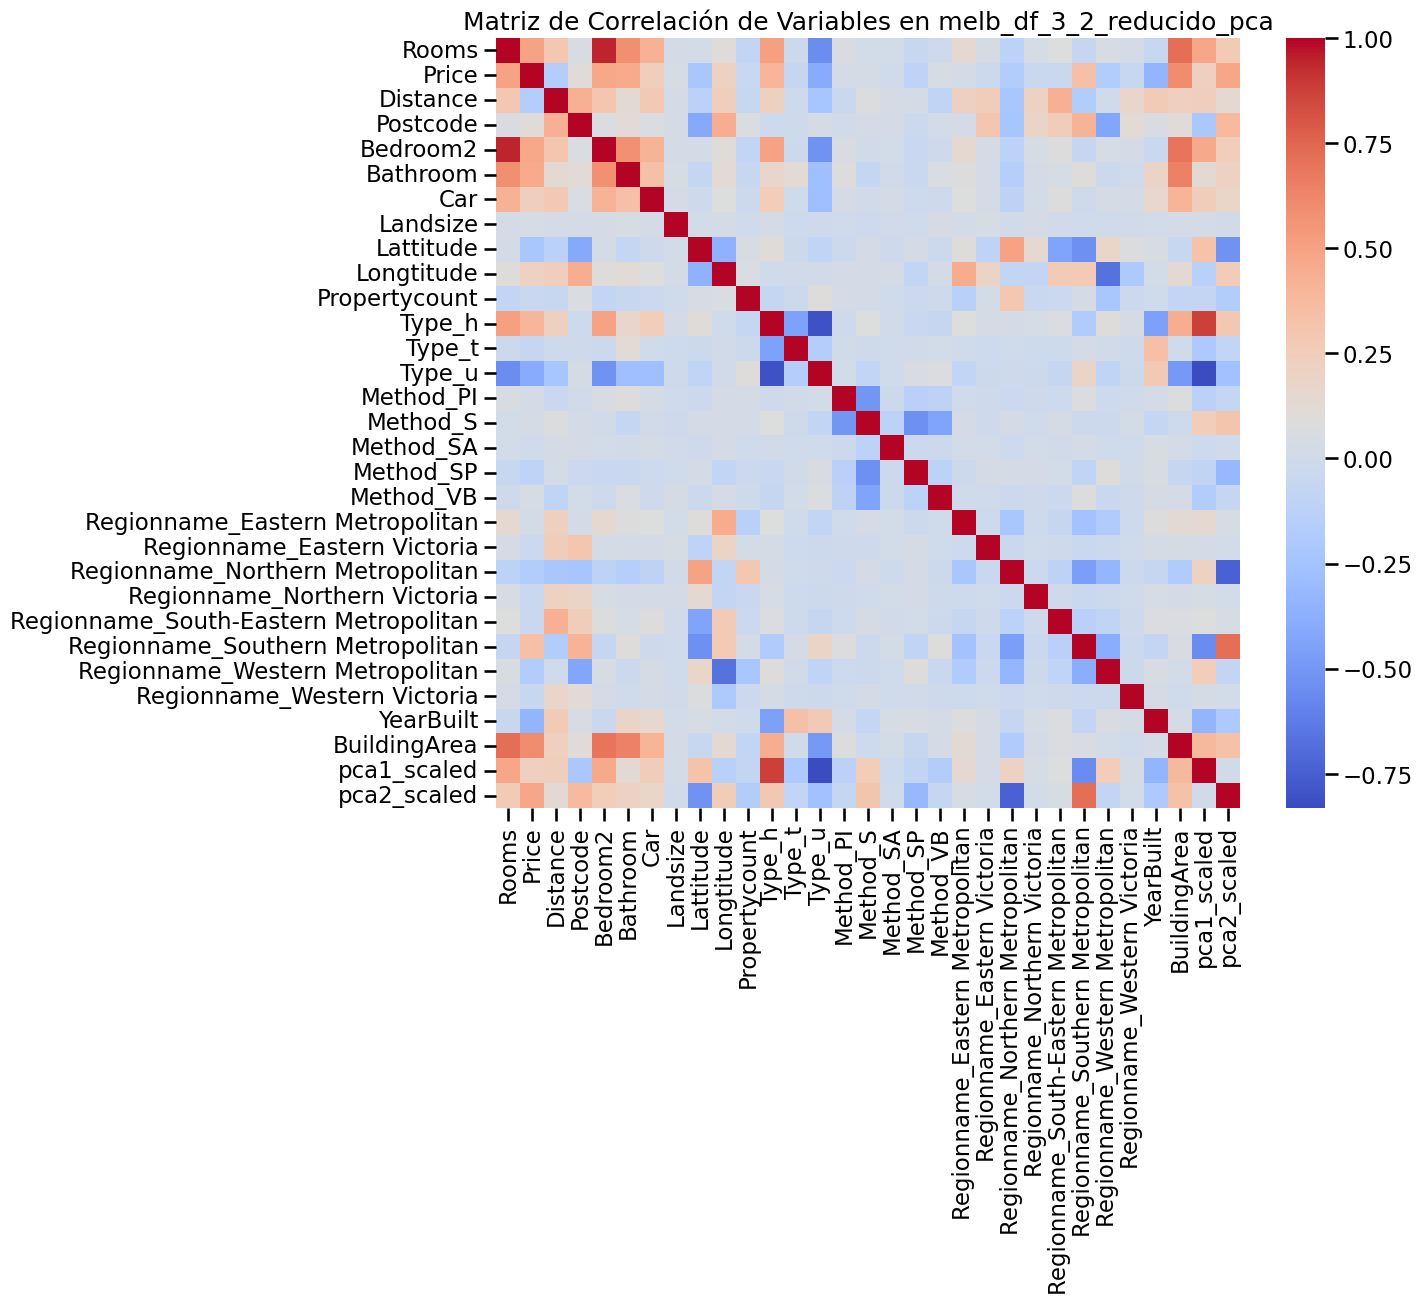

In [ ]:
# Calcula la matriz de correlación
correlation_matrix = melb_df_3_2_reducido_pca.corr()

# Dibuja el mapa de calor de la matriz de correlación
plt.figure(figsize=(12, 10))
seaborn.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Variables en melb_df_3_2_reducido_pca')
plt.show()

Se puede observar una buena correlacion de las columnas PCA 1 y 2 con otras como:
* Rooms
* Price
* Bedroom2
* Type_h
*...


<Axes: xlabel='pca1_scaled', ylabel='pca2_scaled'>

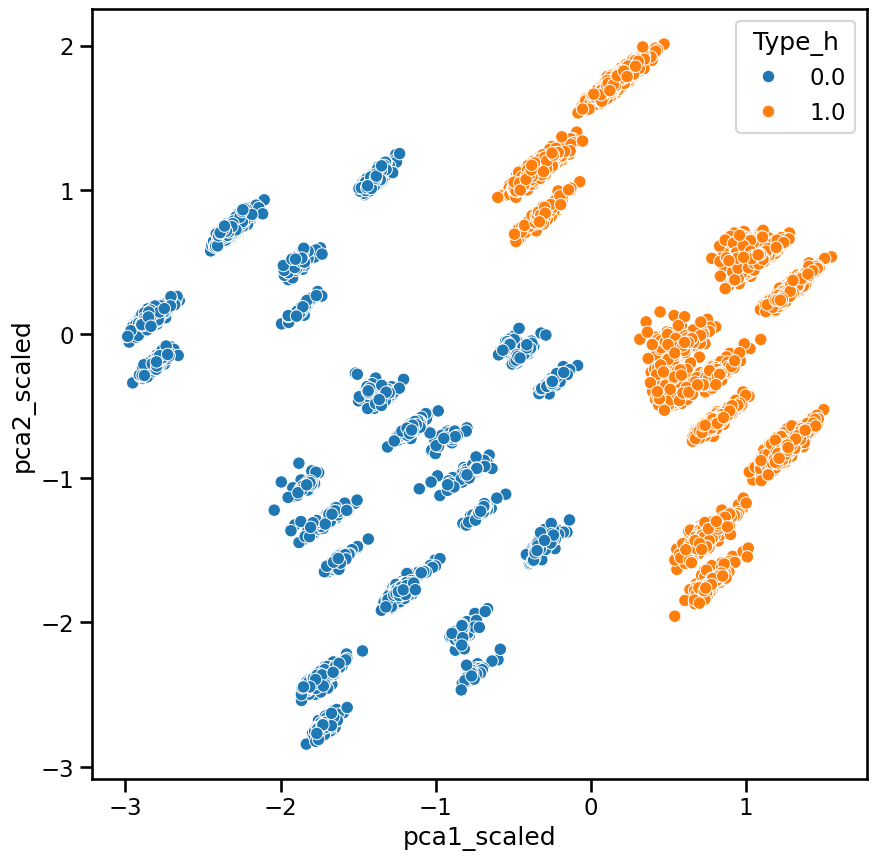

In [ ]:
data = melb_df_3_2_reducido_pca
fig = plt.figure(figsize=(10, 10))
seaborn.scatterplot(data=data, x='pca1_scaled', y='pca2_scaled',
                    hue='Type_h')  # 'Landsize' 'Price' 'YearBuilt'

<Axes: xlabel='pca1_scaled', ylabel='pca2_scaled'>

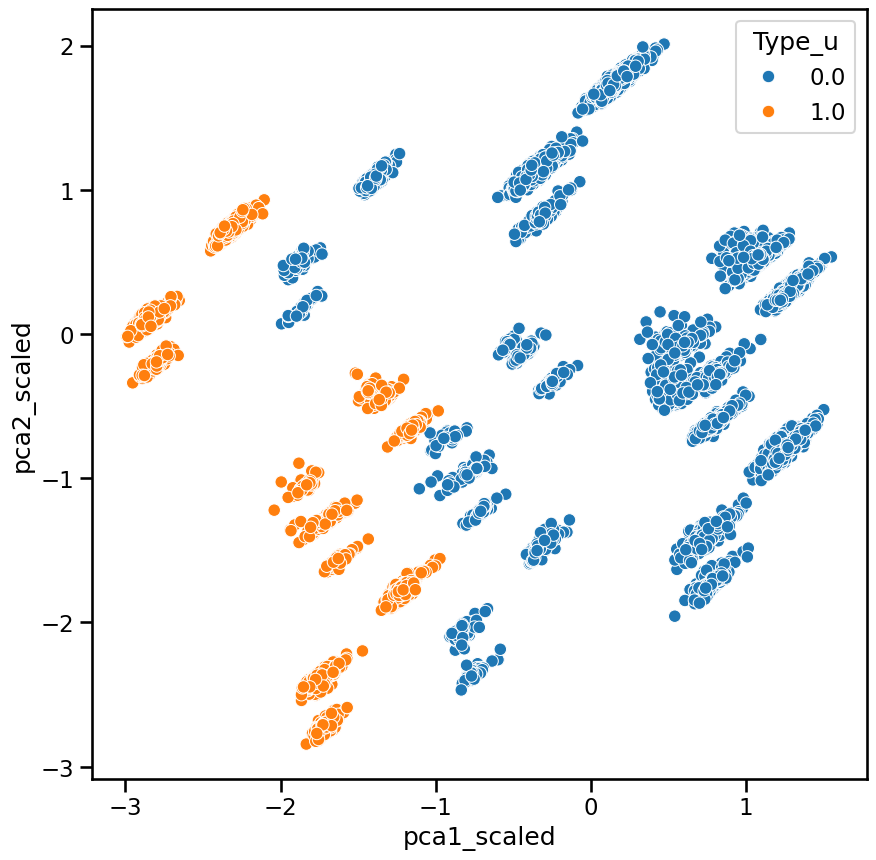

In [ ]:
fig = plt.figure(figsize=(10, 10))
seaborn.scatterplot(data=data, x='pca1_scaled', y='pca2_scaled',
                    hue='Type_u')  # 'Landsize' 'Price' 'YearBuilt'

<Axes: xlabel='pca1_scaled', ylabel='pca2_scaled'>

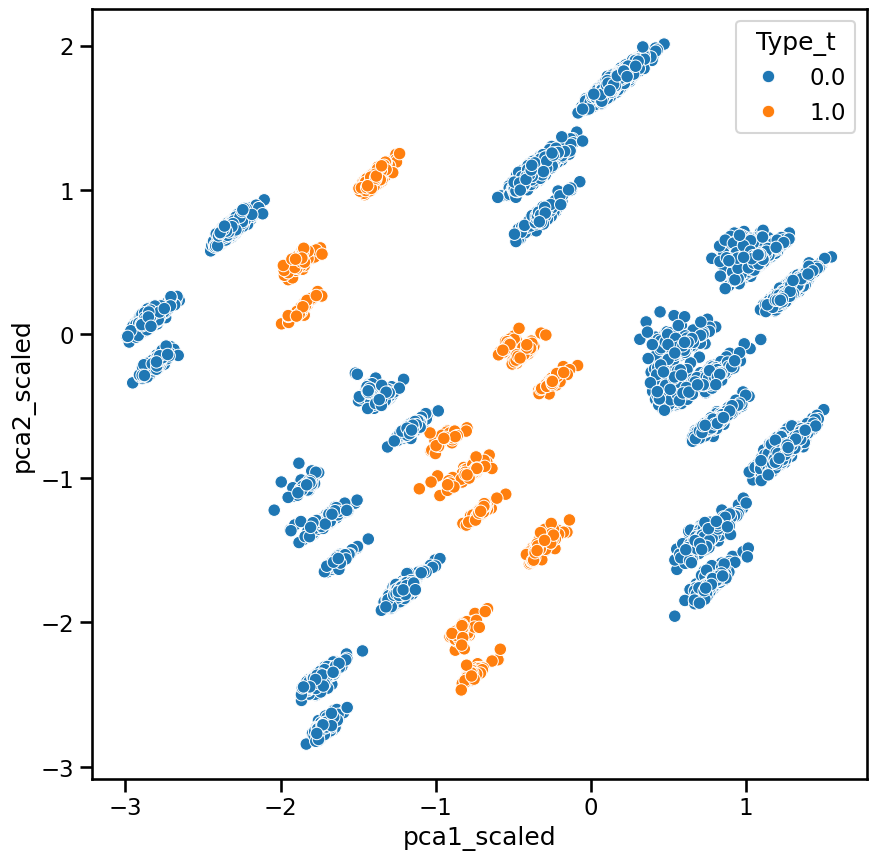

In [ ]:
fig = plt.figure(figsize=(10, 10))
seaborn.scatterplot(data=data, x='pca1_scaled', y='pca2_scaled',
                    hue='Type_t')  # 'Landsize' 'Price' 'YearBuilt'

Este tipo de graficos ayuda a comprender cuánta de la variación relacionada con la característica (“Type_t”, por ejemplo) es capturada por los dos primeros componentes principales. En todos los casos, los dos grupos están bien separados, lo cual indica que estos dos componentes son útiles para la reducción de la dimensionalidad a la vez que preservan la información relevante para identificar las propiedades “Type_t”. En cambio, si hay mucho solapamiento, es posible que se necesiten más componentes principales o características diferentes para distinguir eficazmente esta categoría.

# Ejercicio 4: Composición del resultado

Transformar nuevamente el conjunto de datos procesado en un `pandas.DataFrame` y guardarlo en un archivo.

Para eso, será necesario recordar el nombre original de cada columna de la matriz, en el orden correcto. Tener en cuenta:
1. El método `OneHotEncoder.get_feature_names` o el atributo `OneHotEncoder.categories_` permiten obtener una lista con los valores de la categoría que le corresponde a cada índice de la matriz.
2. Ninguno de los métodos aplicados intercambia de lugar las columnas o las filas de la matriz.

In [ ]:
## Separacion de datos categoricos y numericos:
categorical_cols = columnasCategoricasReducidas # ['Type', 'Method', 'Regionname']
numerical_cols = columnasNumericas #['Rooms', 'Price', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car','Landsize', 'Lattitude', 'Longtitude', 'Propertycount']
new_columns = []

# Step 1: codificar columnas categoricas
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_cat = encoder.fit_transform(melb_df[categorical_cols])
for col, col_values in zip(categorical_cols, encoder.categories_):
  for col_value in col_values:
    new_columns.append('{}={}'.format(col, col_value))
print("Matrix has shape {}, with columns: {}".format(X_cat.shape, new_columns))


# Step 2: unir columnas numericas y categoricas (codificadas)
X = np.hstack([X_cat, melb_df[numerical_cols].values])
new_columns.extend(numerical_cols)
print("Matrix has shape {}, with columns: {}".format(X_cat.shape, new_columns))


# Step 3: imputar valores faltantes
  # Se agregan las columnas YearBuilt y BuildingArea
X = np.hstack([X, melb_df[['YearBuilt','BuildingArea']].values])
new_columns.extend(['YearBuilt', 'BuildingArea'])
  # La imputacion se realiza para las columnas Car, YearBuilt, BuildingArea:
X_temp_df = pd.DataFrame(X, columns=new_columns) # Create a temporary DataFrame to use select_dtypes
melb_data_mice = X_temp_df.select_dtypes(include=np.number)
mice_imputer = IterativeImputer(random_state=10, estimator=KNeighborsRegressor())
result = mice_imputer.fit_transform(melb_data_mice)
# Update the numerical columns in the original numpy array X
# Make sure the order of columns in result matches the order of numerical columns in X
numerical_cols_for_imputation = melb_data_mice.columns.tolist()
numerical_col_indices_in_X = [new_columns.index(col) for col in numerical_cols_for_imputation]

# Assign the imputed values back to the correct columns in the numpy array X
for i, col_index in enumerate(numerical_col_indices_in_X):
    X[:, col_index] = result[:, i]


# Step 4: Append some new features, like PCA
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2)
pca_dummy_features = pca.fit_transform(X_scaled) # Apply PCA on scaled data
X_pca = np.hstack([X, pca_dummy_features])
new_columns.extend(['pca1', 'pca2'])



## Re-build dataframe
processed_melb_df = pd.DataFrame(data=X_pca, columns=new_columns)
processed_melb_df.head()

Matrix has shape (13580, 16), with columns: ['Type=h', 'Type=t', 'Type=u', 'Method=PI', 'Method=S', 'Method=SA', 'Method=SP', 'Method=VB', 'Regionname=Eastern Metropolitan', 'Regionname=Eastern Victoria', 'Regionname=Northern Metropolitan', 'Regionname=Northern Victoria', 'Regionname=South-Eastern Metropolitan', 'Regionname=Southern Metropolitan', 'Regionname=Western Metropolitan', 'Regionname=Western Victoria']
Matrix has shape (13580, 16), with columns: ['Type=h', 'Type=t', 'Type=u', 'Method=PI', 'Method=S', 'Method=SA', 'Method=SP', 'Method=VB', 'Regionname=Eastern Metropolitan', 'Regionname=Eastern Victoria', 'Regionname=Northern Metropolitan', 'Regionname=Northern Victoria', 'Regionname=South-Eastern Metropolitan', 'Regionname=Southern Metropolitan', 'Regionname=Western Metropolitan', 'Regionname=Western Victoria', 'Rooms', 'Price', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'Lattitude', 'Longtitude', 'Propertycount']


,Type=h,Type=t,Type=u,Method=PI,Method=S,Method=SA,Method=SP,Method=VB,Regionname=Eastern Metropolitan,Regionname=Eastern Victoria,...,Bathroom,Car,Landsize,Lattitude,Longtitude,Propertycount,YearBuilt,BuildingArea,pca1,pca2
0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,202.0,-37.7996,144.9984,4019.0,1930.8,162.80000,0.624858,0.267281
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,156.0,-37.8079,144.9934,4019.0,1900.0,79.00000,0.620671,0.271293
2,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,2.0,0.0,134.0,-37.8093,144.9944,4019.0,1900.0,150.00000,0.397391,0.934796
3,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,1.0,94.0,-37.7969,144.9969,4019.0,1959.4,145.98702,0.374752,0.791311
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,2.0,120.0,-37.8072,144.9941,4019.0,2014.0,142.00000,0.372183,0.750842


# Ejercicio 5: Documentación

En un documento `.pdf` o `.md` realizar un reporte de las operaciones que realizaron para obtener el conjunto de datos final. Se debe incluir:
  1. Criterios de exclusión (o inclusión) de filas
  2. Interpretación de las columnas presentes
  2. Todas las transofrmaciones realizadas

Este documento es de uso técnico exclusivamente, y su objetivo es permitir que otres desarrolladores puedan reproducir los mismos pasos y obtener el mismo resultado. Debe ser detallado pero consiso. Por ejemplo:




In [ ]:
pip install fpdf

In [ ]:
from fpdf import FPDF

class PDF(FPDF):
    def header(self):
        self.set_font('Arial', 'B', 14)
        self.cell(0, 10, 'Reporte de las operaciones Realizadas', ln=True, align='C')
        self.ln(5)

    def footer(self):
        self.set_y(-15)
        self.set_font('Arial', 'I', 8)
        self.cell(0, 10, f'Página {self.page_no()}', align='C')

# Crear el PDF
pdf = PDF()
pdf.set_auto_page_break(auto=True, margin=15)
pdf.set_margins(left=10, top=15, right=10)
pdf.add_page()

# Subtítulo
pdf.set_font("Arial", 'B', 11)
pdf.cell(0, 8, "Pasos Detallados", ln=True)

# Texto normal, fuente más pequeña
pdf.set_font("Arial", '', 9)

texto = """
PASO 1: Datos
- Dataset: 'melb_data.csv'
- Fuente: https://cs.famaf.unc.edu.ar/~mteruel/datasets/diplodatos/melb_data.csv

PASO 2: Criterios de exclusión
- Eliminadas variables con alta cardinalidad: 'Suburb', 'Address', 'SellerG', 'Date', 'CouncilArea'

PASO 3: Características seleccionadas
> Categóricas:
  - Type (3 valores), Method (5), Regionname (8)
  - Codificación: OneHotEncoding, DictVectorizer, get_dummies

> Numéricas:
  - Rooms, Price, Distance, Postcode, Bedroom2, Bathroom, Car, Landsize, Latitude, Longitude, Propertycount

Transformaciones aplicadas:
- Filtrado de valores extremos:
   - Car < 5
   - BuildingArea < Q99
   - YearBuilt > Q1

- Imputación (solo Car, BuildingArea, YearBuilt) con:
   - BayesianRidge
   - DecisionTreeRegressor
   - ExtraTreesRegressor
   - KNeighborsRegressor

- Escalado: MinMaxScaler() entre -1 y 1

- PCA: reducción de dimensionalidad con conservación de varianza

PASO 4: Datos aumentados
- Añadidas las 2 primeras componentes obtenidas por PCA al dataset final
"""

pdf.multi_cell(0, 5, texto)  # espacio reducido entre líneas

# 🔁 Salto de página antes de los graficos
pdf.add_page()

# Insertar gráficos (sin cambios, se mantienen en la misma secuencia)
pdf.ln(8)
pdf.set_font("Arial", 'B', 10)
pdf.cell(0, 8, "Gráfico: distribución datos originales", ln=True)
pdf.image("data_original.png", w=180)

pdf.ln(5)
pdf.cell(0, 8, "Gráfico: distribución datos sin valores extremos", ln=True)
pdf.image("data_no_outlayers.png", w=180)

pdf.ln(5)
pdf.cell(0, 8, "Gráfico: datos escalados sin imputar", ln=True)
pdf.image("data_original_scaled.png", w=180)

pdf.ln(5)
pdf.cell(0, 8, "Gráfico: datos escalados e imputados", ln=True)
pdf.image("data_imputed_KNeighborsRegressor.png", w=180)

pdf.ln(5)
pdf.cell(0, 8, "Gráfico: Varianza explicada por componente (PCA)", ln=True)
pdf.image("pca_variance_plot.png", w=180)

# 🔁 Salto de página antes de la conclusión
pdf.add_page()

# Conclusión
pdf.set_font("Arial", 'B', 12)
pdf.cell(0, 10, "Conclusiones", ln=True)

pdf.set_font("Arial", 'I', 11)
pdf.multi_cell(0, 8, """El análisis y procesamiento del dataset mlb_data permitió construir una versión optimizada, limpia y adecuada para tareas de modelado predictivo. Se seleccionaron variables relevantes (tanto numéricas como categóricas), eliminando aquellas con alta cardinalidad o escasa utilidad. Se aplicaron técnicas robustas de imputación para tratar los valores faltantes, junto con una estandarización que garantiza una mejor comparabilidad entre atributos. Finalmente, la incorporación de componentes principales mediante PCA permitió reducir la dimensionalidad sin perder información clave, facilitando así un análisis más eficiente y preciso.

En resumen, el conjunto de datos resultante es consistente, representativo y apto para aplicaciones de machine learning o estudios exploratorios avanzados.""")

# Guardar PDF
pdf.output("informe_melb_df.pdf")


''

```
  ## Datos
  1. Se trabajo con el dataset mlb_data:
    - Fuente: 'https://cs.famaf.unc.edu.ar/~mteruel/datasets/diplodatos/melb_data.csv'
  
  ## Criterios de exclusión
  1. Con el fin de obtener un Data Frame manejable, se eliminan las variables categoricas 'Suburb', 'Address', 'SellerG' , 'Date' y 'CouncilArea' ya que tienen demasiadas valores diferentes (mas de 30 por cada variable).

  ## Características seleccionadas
  ### Características categóricas
  1. Type: tipo de propiedad. 3 valores posibles
  2. Method: Método de venta. 5 valores posibles
  3. Regionname:  Región general de ubicación. 8 valores posibles.
  Todas las características categóricas fueron codificadas mediante 3 opciones:
  - OneHotEncoding + np.hstack
  - DictVectorizer + np.hstack
  - get_dummies + concat

  
  ### Características numéricas
  1. Rooms: Cantidad de habitaciones
  2. Price: Precio de venta.
  3. Distance: Distancia al centro de Melbourne (en km).                          
  4. Postcode: Codigo postal.
  5. Bedroom2: Número de dormitorios extraído de una fuente alternativa mediante web scraping. Puede diferir de la variable principal de habitaciones (Rooms).
  6. Bathroom: Número de baños en la propiedad. Es un factor importante para estimar el valor y la comodidad de la vivienda.  
  7. Car: Número de espacios disponibles para estacionamiento de automóviles. También puede influir en el valor de la propiedad, especialmente en zonas urbanas.
  8. Landsize: Tamaño del terreno (en metros cuadrados). Es relevante para propiedades con patios o jardines, y puede impactar fuertemente en el precio.
  9. Lattitude: Latitud.
  10.Longtitude: Longitud.
  11.Propertycount:                           
  

  ### Transformaciones:
  1. Se eliminaron datos extremos segun el siguiente criterio:
    - Car: menores a 5
    - BuildingArea: menores a cuartil 99
    - YearBuilt: mayores al cuartil 1

  2. Se realiza la imputacion de las variables Car, BuildingArea y YearBuilt, ya que son las unicas con valores faltantes, mediante el metodo de imputacion multiple aplicando los siguientes estimadores:
    - BayesianRidge
    - DecisionTreeRegressor
    - ExtraTreesRegressor
    - KNeighborsRegressor

  3. Todas las características numéricas fueron estandarizadas entre -1 y 1 mediante MinMaxScaler().
  
  4. Se aplico PCA para determinar las n componente principales.

  ### Datos aumentados
  1. Se agregan las 2 primeras columnas obtenidas a través del
     método de PCA, aplicado sobre el conjunto de datos
     totalmente procesado.
```